# Task 1. Exploratory analysis of the Spiff price series

Task 1 in the project asks for a thorough analysis of the seven series, with particular attention to patterns within each series, relationships between the series, and whether the assets can be grouped. The PDF also suggests that returns should be the main working object, since price levels are likely to be nonstationary.

This notebook is therefore organized around three questions:

1. What do the individual price and return series look like?
2. What serial dependence remains after transforming prices to returns?
3. Which assets move together strongly enough to justify grouping?


In [34]:
from pathlib import Path
import sys


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.signal import periodogram
from scipy.spatial.distance import squareform
from scipy.stats import jarque_bera
from statsmodels.graphics.gofplots import qqplot

repo_root = Path.cwd()
sys.path.append(str(repo_root.parent))

from config.plot_config import plot_config
from Subtasks.series_analysis import (
    PriceAnalysis,
    build_return_feature_table,
    classify_volatility_regimes,
    fill_missing_with_series_mean,
    ljung_box_conclusion_table,
    pair_same_regime_correlation_summary,
    plot_cluster_scatter,
    plot_pairwise_stability_heatmap,
    plot_cumulative_explained_variance,
    plot_pca_projection,
    plot_regime_conditional_correlation_matrices,
    plot_regime_correlation_differences,
    plot_rolling_volatility_regimes,
    plot_series_with_regime_overlay,
    plot_volatility_regime_heatmap,
    plot_volatility_regime_shares,
    print_cluster_groups,
    regime_conditional_correlation_matrices,
    regime_conditional_correlation_summary,
    remove_self_correlations,
    rolling_correlation_stability_matrix,
    rolling_correlation_stability_summary,
    rolling_pairwise_correlations,
    run_asset_clustering,
    stationarity_summary,
    standardized_return_path_pca,
    summarize_volatility_regimes,
    system_volatility_regime,
    volatility_regime_spells,
    volatility_regime_transition_summary,
    wide_regime_correlation_summary,
)


output = plot_config() / "task1"
output.mkdir(exist_ok=True)


## 1. Load the raw data


In [35]:
raw_data = PriceAnalysis.from_csv("spiff_data-2.csv")
raw_prices = raw_data.prices
raw_prices.reset_index().iloc[:5].to_latex(output / "DataExample")
raw_prices.reset_index().head()

,day,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
0,1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
1,2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
2,3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
3,4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
4,5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026


If the observations are daily, the dataset covers about 22 years. That length is useful for separating short-run volatility, medium-run correlation changes, and slow trend or seasonal components.


## 2. Data quality and cleaning

Before studying any time-series structure, we first check whether the raw dataset contains implausible observations or systematic missingness. This is essential because a few corrupted rows can dominate sample means, variances, correlations, and autocorrelations.


In [36]:
raw_overview = raw_data.overview()
print(f"Shape: {raw_prices.shape}")
display(raw_overview)


Shape: (5456, 7)


,dtype,missing_values,missing_share
gurkor,float64,250,0.045821
guitars,float64,250,0.045821
slingshots,float64,250,0.045821
stocks,float64,250,0.045821
sugar,float64,250,0.045821
water,float64,250,0.045821
tranquillity,float64,250,0.045821


The raw price plot is useful for spotting level shifts, obvious trends, and values that are completely out of scale with their neighbors.


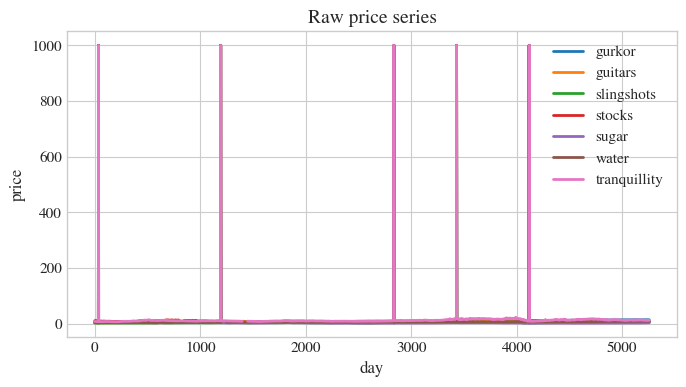

In [37]:
fig, ax = plt.subplots()
for column in raw_prices.columns:
    ax.plot(raw_prices.index, raw_prices[column], label=column)
ax.set_title("Raw price series")
ax.set_xlabel("day")
ax.set_ylabel("price")
ax.legend()

plt.tight_layout()
plt.savefig(output / "raw_price_series.png", bbox_inches="tight")
plt.show()


Rows where every asset takes the exact value 1000 are best interpreted as placeholders or corrupted observations rather than genuine prices. Keeping them would create artificial jumps in both returns and dependence measures, so they are removed before the main analysis.


In [38]:
placeholder_value = 1_000
placeholder_rows = raw_data.placeholder_rows(placeholder_value)
cleaned_data = raw_data.clean(placeholder_value)
cleaned_prices = cleaned_data.prices
cleaned_overview = pd.DataFrame(
    {
        "missing_values_after_cleaning": cleaned_prices.isna().sum(),
        "missing_share_after_cleaning": cleaned_prices.isna().mean(),
    }
)

display(placeholder_rows.reset_index())
display(cleaned_overview)


,day,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
0,36,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
1,1194,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
2,2836,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
3,3430,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
4,4118,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0


,missing_values_after_cleaning,missing_share_after_cleaning
gurkor,255,0.046738
guitars,255,0.046738
slingshots,255,0.046738
stocks,255,0.046738
sugar,255,0.046738
water,255,0.046738
tranquillity,255,0.046738


Each series then contains one internal 50-day gap, and all series share a final block of 200 missing values. That structure matters for later tasks: interpolation must handle one interior gap per asset, while extrapolation must handle a shared missing tail.


In [39]:
missing_blocks = cleaned_data.missing_summary()
display(missing_blocks)

,block_1,block_2
gurkor,199-248 (50 days),5257-5456 (200 days)
guitars,399-448 (50 days),5257-5456 (200 days)
slingshots,599-648 (50 days),5257-5456 (200 days)
stocks,799-848 (50 days),5257-5456 (200 days)
sugar,999-1048 (50 days),5257-5456 (200 days)
water,1199-1248 (50 days),5257-5456 (200 days)
tranquillity,1399-1448 (50 days),5257-5456 (200 days)


## Cleaned price plot


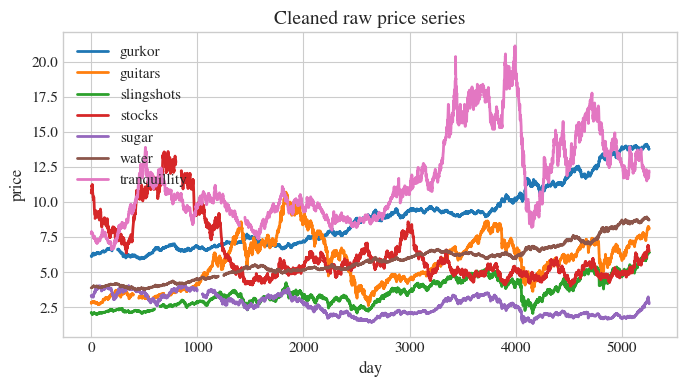

In [40]:
fig, ax = plt.subplots()
for column in cleaned_prices.columns:
    ax.plot(cleaned_prices.index, cleaned_prices[column], label=column)
ax.set_title("Cleaned raw price series")
ax.set_xlabel("day")
ax.set_ylabel("price")
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(output / "cleaned_raw_price_series.png", bbox_inches="tight")
plt.show()

## 3. Stationarity

We use two complementary stationarity tests.

The Augmented Dickey-Fuller (ADF) test has **nonstationarity / unit root** as the null hypothesis, so a small ADF p-value supports stationarity. The KPSS test has **stationarity** as the null hypothesis, so a small KPSS p-value supports nonstationarity. Reading them together is useful because agreement is much stronger evidence than either test alone.

For the combined conclusion below:

- **Stationary** means ADF rejects a unit root and KPSS does not reject stationarity.
- **Non-stationary** means ADF does not reject a unit root and KPSS rejects stationarity.
- **Mixed evidence** means the two tests disagree, so the transformation choice should be treated more cautiously.


In [41]:
price_stationarity_table = stationarity_summary(cleaned_prices)
#display(price_stationarity_table)
display(price_stationarity_table[['series','stationarity_conclusion']])


,series,stationarity_conclusion
0,gurkor,Non-stationary
1,guitars,Non-stationary
2,slingshots,Non-stationary
3,stocks,Non-stationary
4,sugar,Non-stationary
5,water,Non-stationary
6,tranquillity,Non-stationary


For cleaned price levels, the tests agree for every asset: ADF does not reject a unit root, while KPSS rejects level stationarity. This matches the visual impression that the price levels are highly persistent and should not be treated as stationary modeling targets.


## 4. Transformations and analysis settings

The project statement explicitly suggests using returns rather than raw prices for most of the analysis. Let $X_t$ denote the price at time $t$. We work with log-returns

$$
r_t = \log X_t - \log X_{t-1}.
$$

This removes most of the low-frequency price-level persistence and makes the series comparable across assets with different price scales.


In [42]:
log_return_data = cleaned_data.log_returns
absolute_log_return_data = cleaned_data.absolute_log_returns
squared_log_return_data = cleaned_data.squared_log_returns


In [43]:
return_stationarity_table = stationarity_summary(log_return_data)
#display(return_stationarity_table)
display(return_stationarity_table[['series','stationarity_conclusion']])


,series,stationarity_conclusion
0,gurkor,Stationary
1,guitars,Stationary
2,slingshots,Stationary
3,stocks,Stationary
4,sugar,Stationary
5,water,Stationary
6,tranquillity,Stationary


For log-returns, the tests also agree for every asset: ADF rejects a unit root, while KPSS does not reject stationarity. This supports using log-returns for dependence, correlation, grouping, and volatility analysis.


## 5. Within-series patterns


### Price levels and log-returns

The left panels show the cleaned price levels. These are useful for checking trend, persistence, structural breaks, and changing scale. The right panels show the corresponding log-returns, which should look more stable if differencing removes the main nonstationary component.


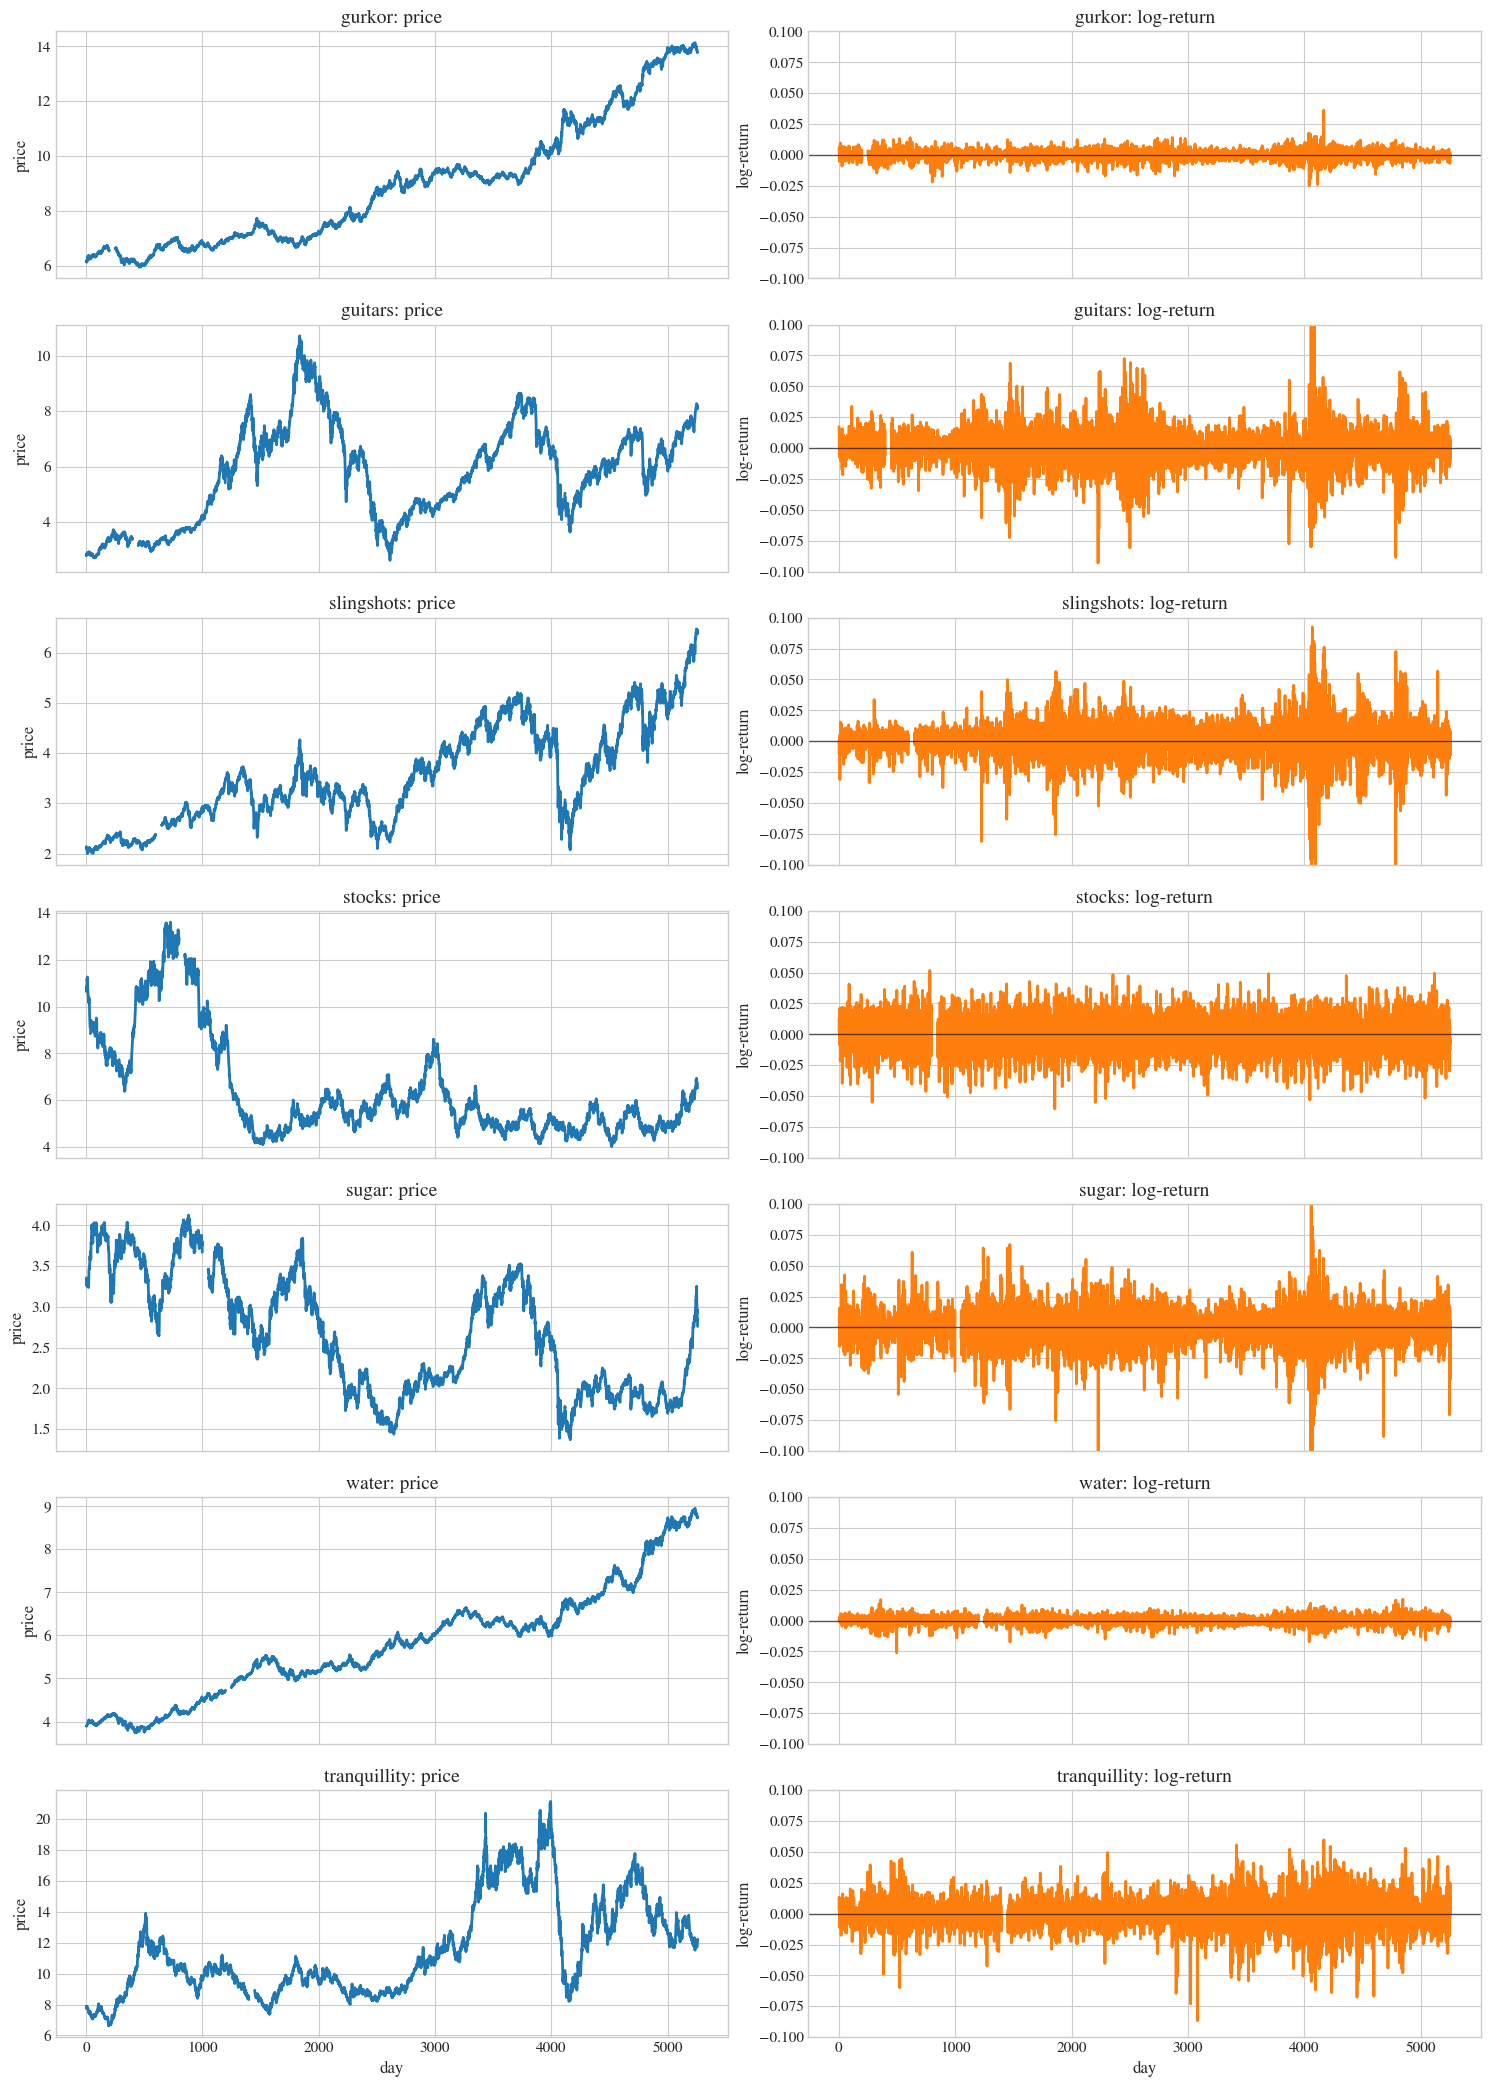

In [44]:
fig, axes = plt.subplots(len(cleaned_prices.columns), 2, figsize=(15, 3 * len(cleaned_prices.columns)), sharex=True, squeeze=False)

for row, column in enumerate(cleaned_prices.columns):
    axes[row, 0].plot(cleaned_prices.index, cleaned_prices[column], color="tab:blue")
    axes[row, 0].set_title(f"{column}: price")
    axes[row, 0].set_ylabel("price")

    axes[row, 1].plot(log_return_data.index, log_return_data[column], color="tab:orange")
    axes[row, 1].axhline(0, color="black", linewidth=1, alpha=0.6)
    axes[row, 1].set_title(f"{column}: log-return")
    axes[row, 1].set_ylabel("log-return")
    axes[row, 1].set_ylim(-0.1,0.1)


for ax in axes[-1, :]:
    ax.set_xlabel("day")

plt.tight_layout()
plt.savefig(output / "price_levels_and_log_returns.png", bbox_inches="tight")
plt.show()


Main visual patterns:

- All price levels are persistent; several have visible low-frequency trend or regime-like movement.
- Log-returns are centered close to zero and much more stable than the price levels.
- Volatility scale differs sharply: `gurkor` and `water` have much smaller return volatility than the other assets.
- Large return spikes are concentrated in episodes, which motivates checking volatility clustering rather than relying only on raw return autocorrelation.


### Distributional shape and rolling stability

The histogram and QQ-plot focus on the one-period distribution of $r_t = \Delta \log X_t$. The rolling mean and rolling variance below are also computed from log-returns, not from raw price levels, and ask whether the transformed return series look approximately stable over time.


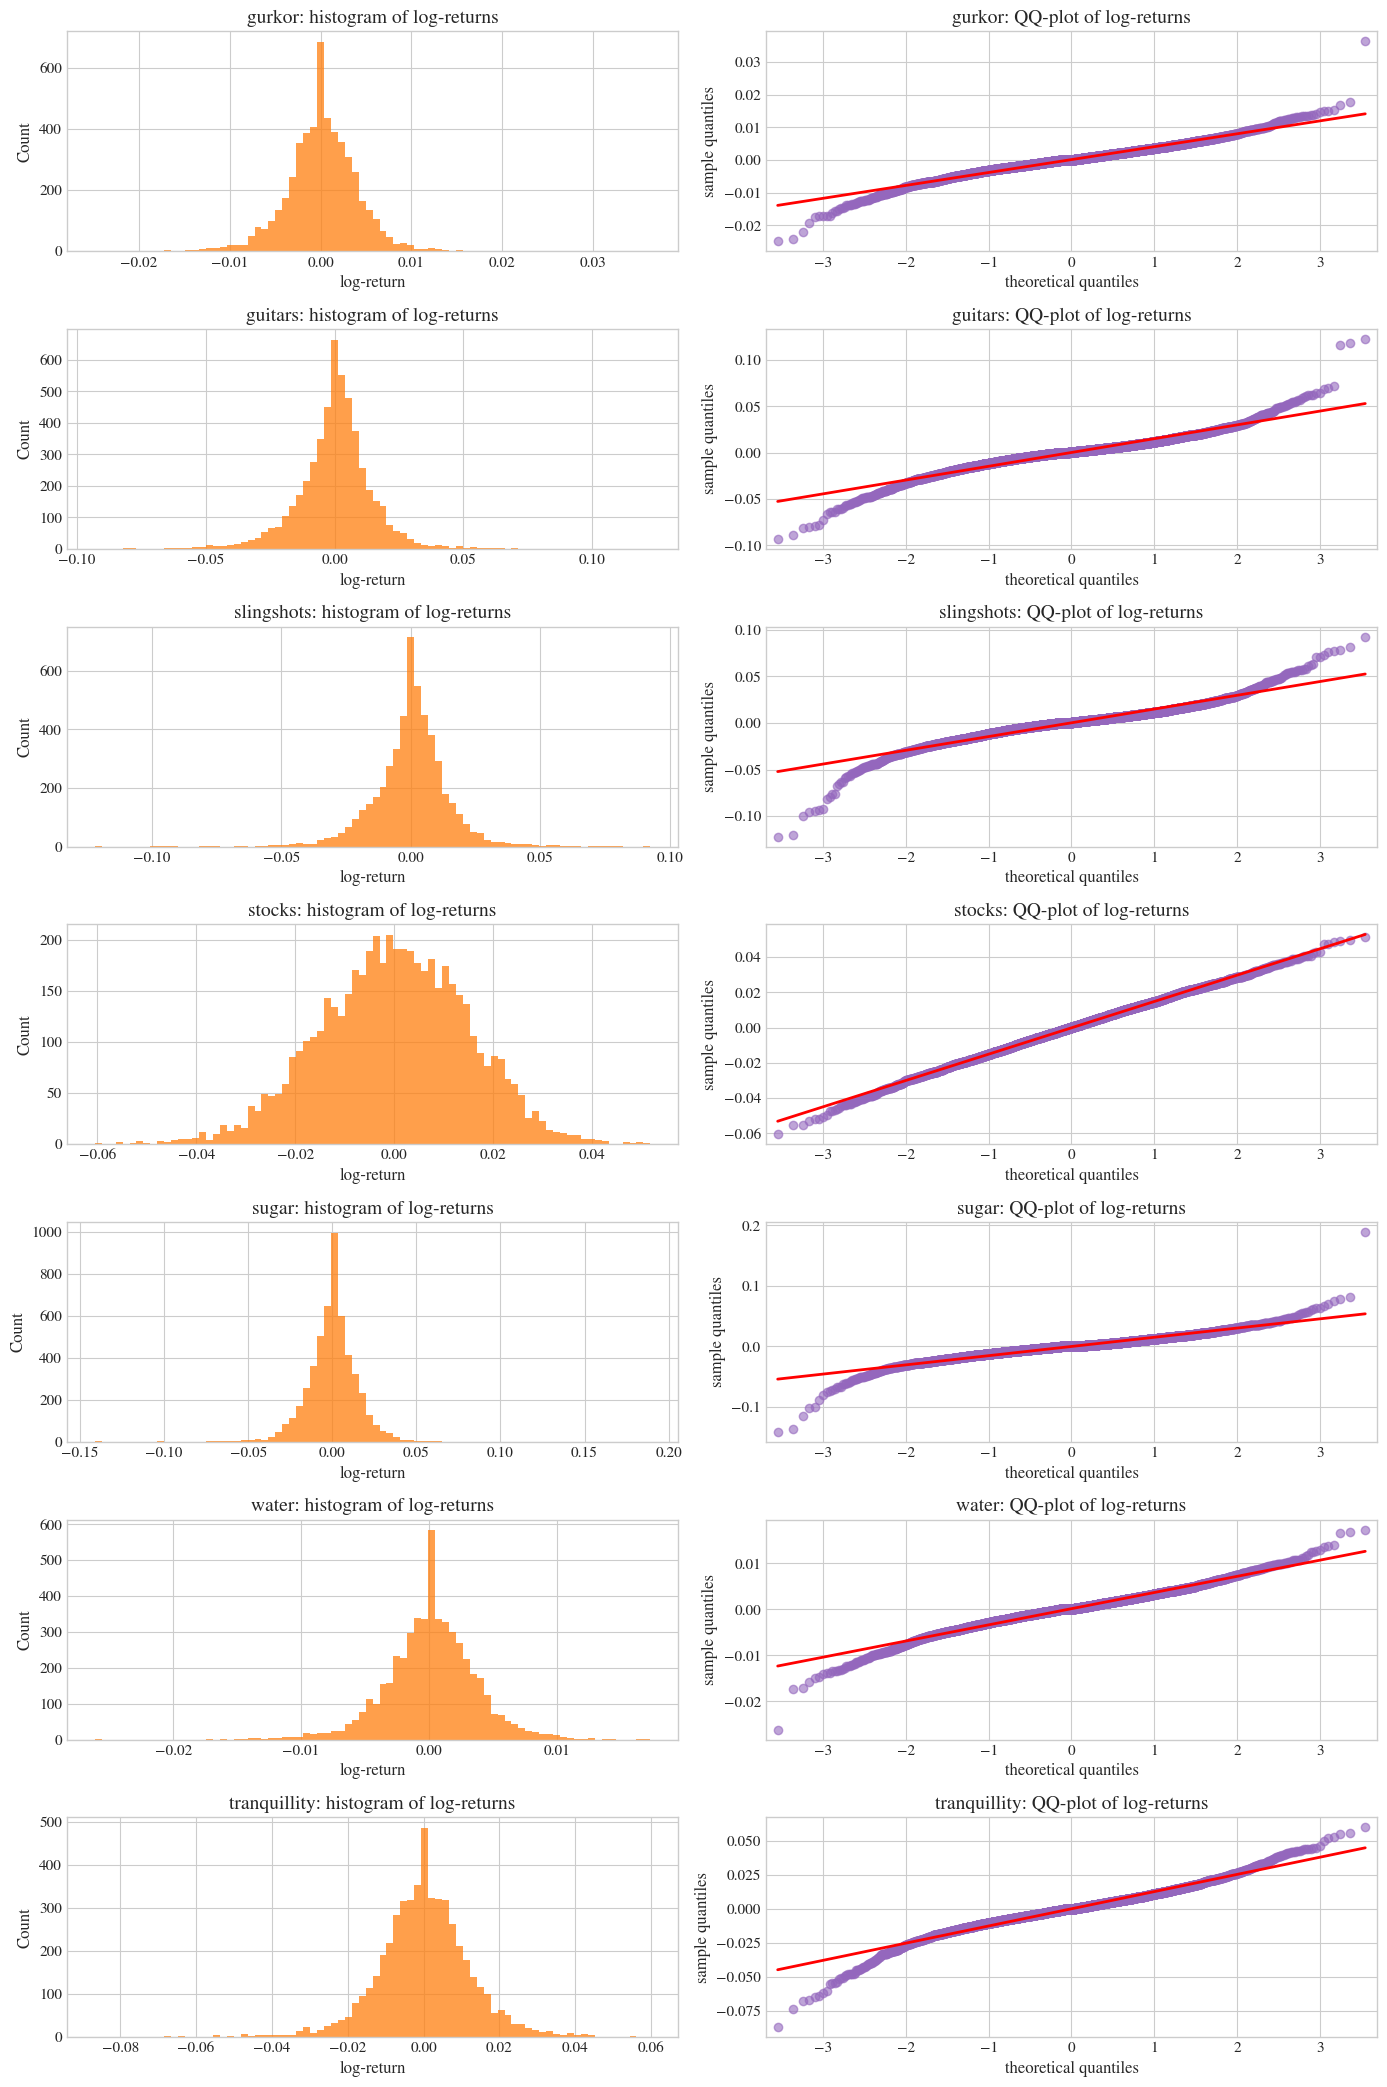

In [45]:
fig, axes = plt.subplots(len(cleaned_prices.columns), 2, figsize=(14, 3 * len(cleaned_prices.columns)), squeeze=False)

for row, column in enumerate(cleaned_prices.columns):
    series = log_return_data[column].dropna()

    sns.histplot(series, bins=80, ax=axes[row, 0], color="tab:orange", edgecolor=None)
    axes[row, 0].set_title(f"{column}: histogram of log-returns")
    axes[row, 0].set_xlabel("log-return")

    qqplot(series, line="s", ax=axes[row, 1], markerfacecolor="tab:purple", markeredgecolor="tab:purple", alpha=0.6)
    axes[row, 1].set_title(f"{column}: QQ-plot of log-returns")
    axes[row, 1].set_xlabel("theoretical quantiles")
    axes[row, 1].set_ylabel("sample quantiles")

plt.tight_layout()
plt.savefig(output / "log_return_histograms_qqplots.png", bbox_inches="tight")
plt.show()


In [46]:
log_return_summary = pd.DataFrame(
    {
        "mean": log_return_data.mean(),
        "std": log_return_data.std(),
        "skewness": log_return_data.skew(),
        "excess_kurtosis": log_return_data.kurtosis(),
        "min": log_return_data.min(),
        "q01": log_return_data.quantile(0.01),
        "q05": log_return_data.quantile(0.05),
        "q95": log_return_data.quantile(0.95),
        "q99": log_return_data.quantile(0.99),
        "max": log_return_data.max(),
        "jarque_bera_pvalue": [jarque_bera(log_return_data[col].dropna()).pvalue for col in log_return_data.columns],
    }
).sort_values("std", ascending=False)

display(log_return_summary.round(6))


,mean,std,skewness,excess_kurtosis,min,q01,q05,q95,q99,max,jarque_bera_pvalue
sugar,-0.000014,0.015209,-0.238585,10.704963,-0.141238,-0.040494,-0.024080,0.022844,0.037608,0.189156,0.000000
stocks,-0.000074,0.014935,-0.124211,0.077238,-0.060469,-0.036058,-0.025085,0.023848,0.033470,0.051696,0.000676
guitars,0.000236,0.014876,-0.034939,5.558723,-0.093062,-0.043511,-0.024076,0.022063,0.041037,0.122535,0.000000
slingshots,0.000194,0.014747,-0.444992,6.438702,-0.121902,-0.041969,-0.022977,0.021512,0.041091,0.092500,0.000000
tranquillity,0.000078,0.012589,-0.271848,2.976584,-0.086687,-0.035192,-0.019190,0.020294,0.033161,0.059772,0.000000
gurkor,0.000155,0.003945,-0.146980,3.517657,-0.024838,-0.010744,-0.006459,0.006285,0.009916,0.036285,0.000000
water,0.000152,0.003515,-0.259686,2.250074,-0.026131,-0.009685,-0.005505,0.005680,0.008997,0.017331,0.000000


The distribution plots show that `stocks` is closest to Gaussian among the seven assets. The other return distributions have visibly heavier tails, especially `sugar`, `slingshots`, and `guitars`.


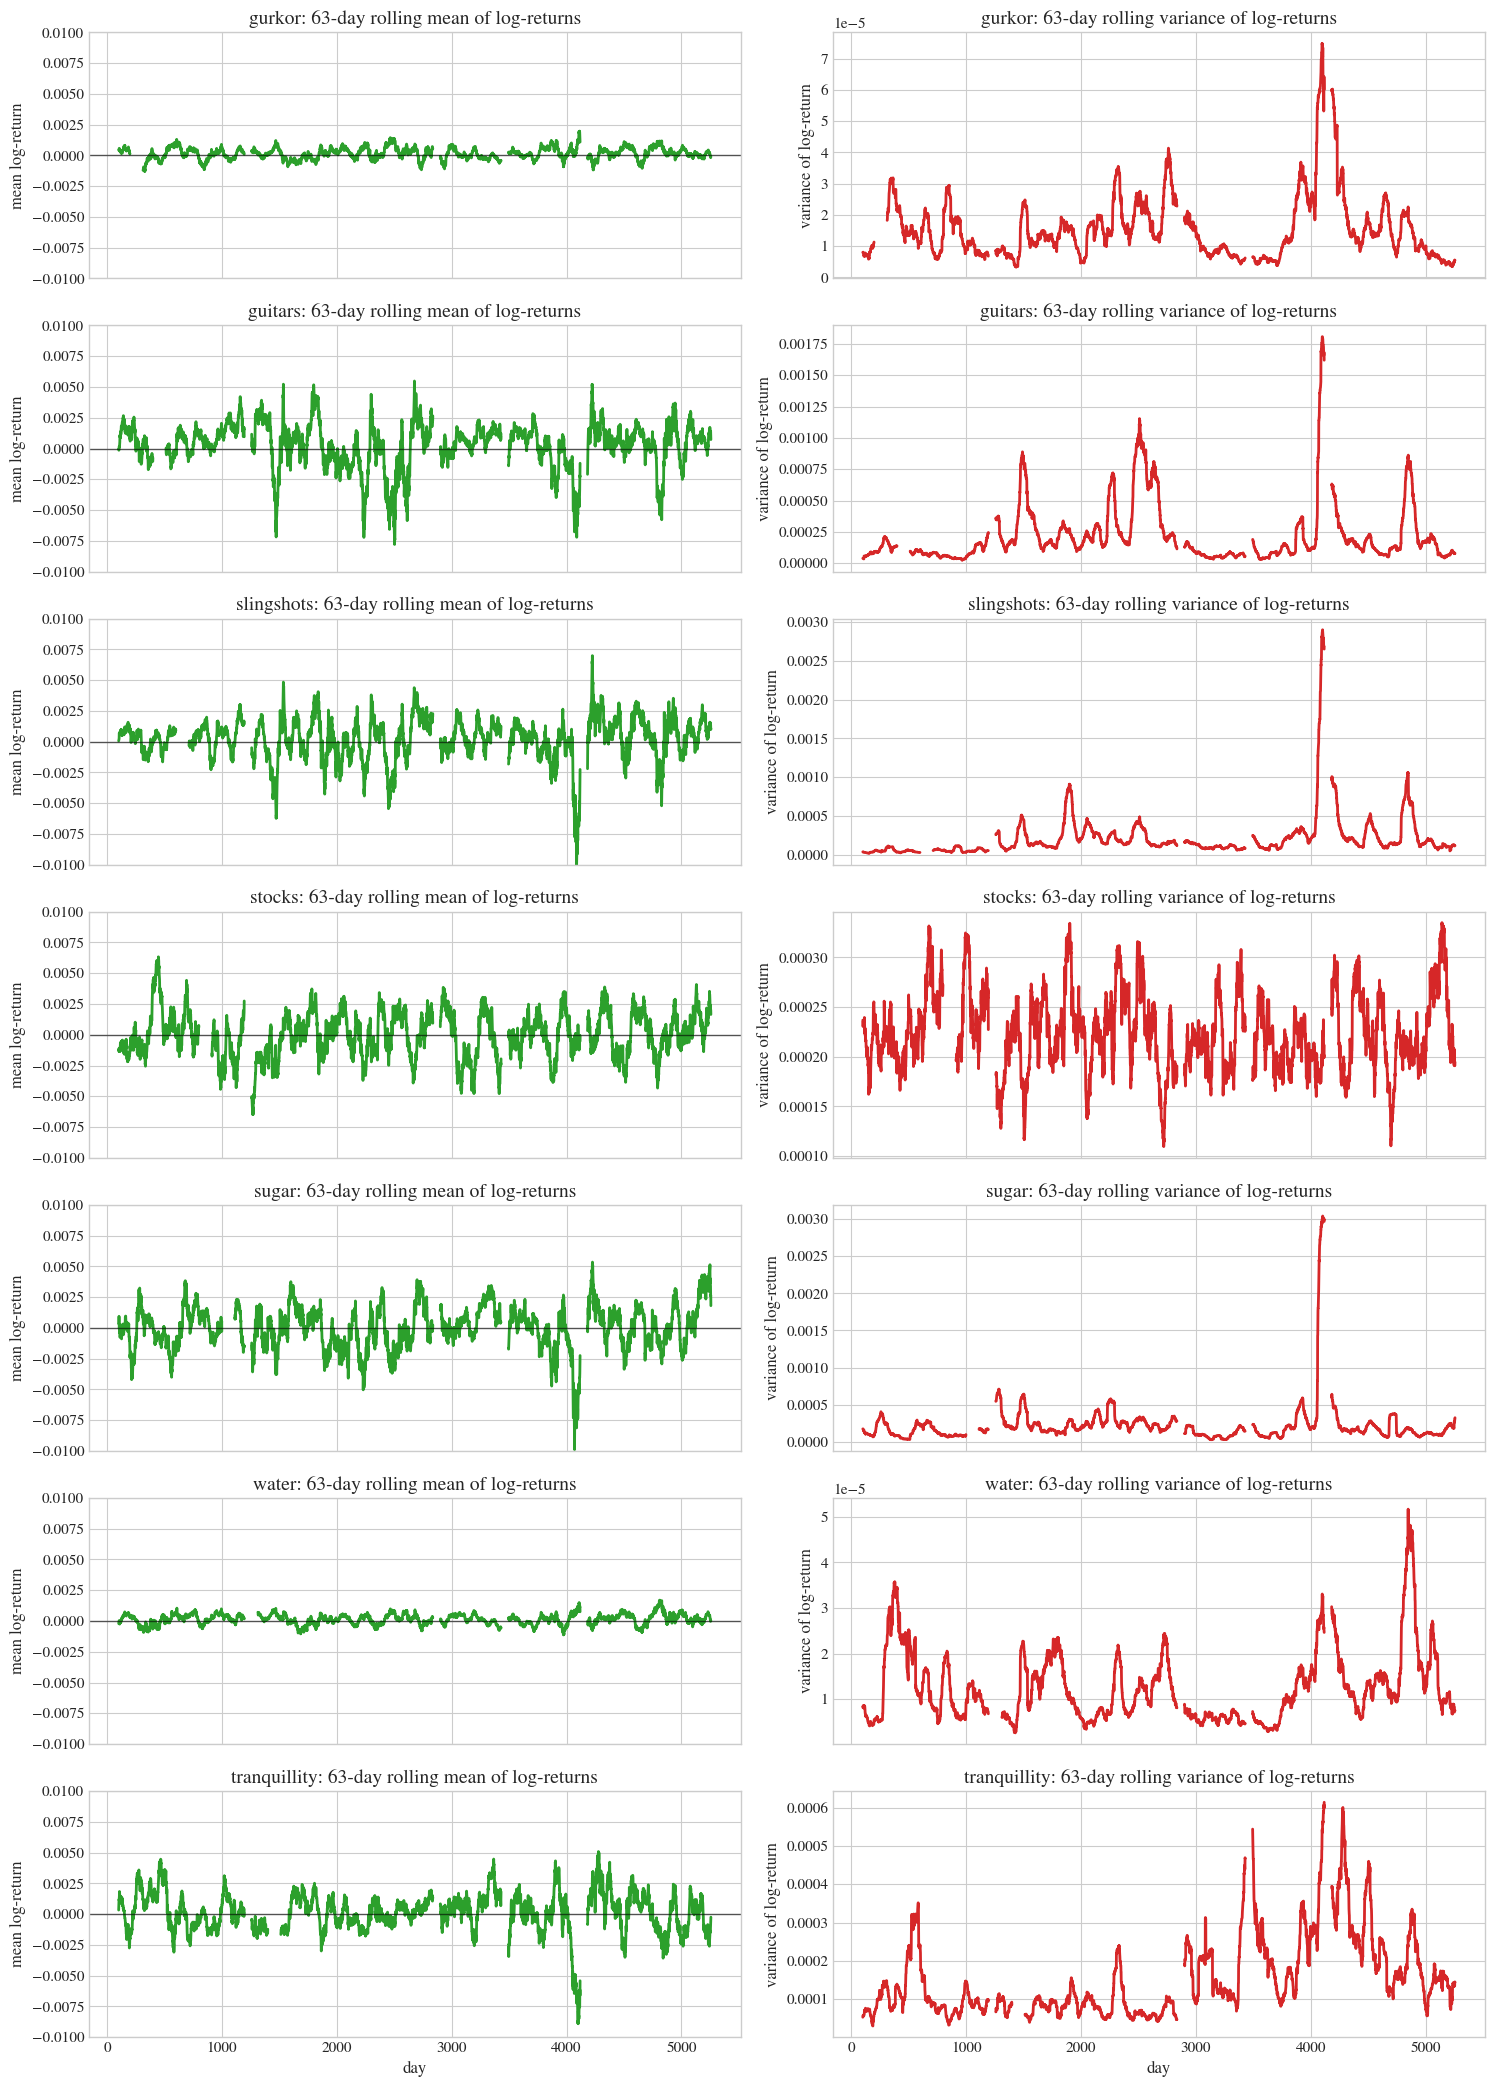

In [47]:
rolling_window = 63  # roughly one quarter of trading days

rolling_log_return_mean = cleaned_data.rolling_mean(window=rolling_window)
rolling_log_return_variance = cleaned_data.rolling_variance(window=rolling_window)

fig, axes = plt.subplots(len(cleaned_prices.columns), 2, figsize=(15, 3 * len(cleaned_prices.columns)), squeeze=False,sharex=True)

for row, column in enumerate(cleaned_prices.columns):
    axes[row, 0].plot(rolling_log_return_mean.index, rolling_log_return_mean[column], color="tab:green")
    axes[row, 0].axhline(0, color="black", linewidth=1, alpha=0.6)
    axes[row, 0].set_title(f"{column}: {rolling_window}-day rolling mean of log-returns")
    axes[row, 0].set_ylim(-0.01,0.01)

    axes[row, 0].set_ylabel("mean log-return")

    axes[row, 1].plot(rolling_log_return_variance.index, rolling_log_return_variance[column], color="tab:red")
    axes[row, 1].set_title(f"{column}: {rolling_window}-day rolling variance of log-returns")
    axes[row, 1].set_ylabel("variance of log-return")


axes[row, 0].set_xlabel("day")
axes[row, 1].set_xlabel("day")


plt.tight_layout()
plt.savefig(output / "rolling_mean_variance.png", bbox_inches="tight")
plt.show()


The rolling variance plots show persistent high- and low-volatility episodes in most assets. This is the key empirical reason to consider conditional-variance models, such as GARCH, in Task 2.


## 6. Serial dependence and volatility clustering

We now check whether dependence remains after transforming prices to returns. The ACF and PACF give lag-by-lag evidence, while Ljung-Box tests summarize whether a block of autocorrelations is jointly different from zero.


### ACF and PACF of the cleaned price levels

For a transformed series $z_t$, the sample autocorrelation at lag $k$ is

$$
\hat\rho_k = \frac{\sum_{t=k+1}^T (z_t - \bar z)(z_{t-k} - \bar z)}{\sum_{t=1}^T (z_t - \bar z)^2}.
$$

The PACF then isolates the direct contribution of lag $k$ after controlling for lags $1, \ldots, k-1$. If the raw price series are nonstationary, their ACFs should decay slowly rather than cutting off quickly, while the PACF should not show a clean short-order cutoff.


In [48]:
def plot_dual_serial_correlation_grid(data, analysis, max_lag, label, acf_color="tab:blue", pacf_color="tab:green"):
    lags = np.arange(max_lag + 1)
    fig, axes = plt.subplots(len(data.columns), 2, figsize=(15, 2.8 * len(data.columns)), squeeze=False)

    for row, column in enumerate(data.columns):
        series = data[column].dropna()
        acf_values = analysis.sample_acf(series, max_lag=max_lag)
        pacf_values = analysis.sample_pacf(series, max_lag=max_lag)
        confidence_band = 1.96 / np.sqrt(len(series))

        for ax, values, title, color in [
            (axes[row, 0], acf_values, "ACF", acf_color),
            (axes[row, 1], pacf_values, "PACF", pacf_color),
        ]:
            ax.axhline(0, color="black", linewidth=1)
            ax.axhline(confidence_band, color="tab:red", linestyle="--", linewidth=1)
            ax.axhline(-confidence_band, color="tab:red", linestyle="--", linewidth=1)
            ax.stem(lags, values, basefmt=" ", linefmt=color, markerfmt="o")
            ax.set_title(f"{column}: {title} of {label}")
            ax.set_ylabel(title)
            ax.set_xlim(-0.5, max_lag + 0.5)

    for ax in axes[-1, :]:
        ax.set_xlabel("lag")

    plt.tight_layout()
    safe_label = label.lower().replace(" ", "_").replace("-", "_")
    plt.savefig(output / f"acf_pacf_{safe_label}.png", bbox_inches="tight")
    plt.show()


### ACF and PACF of log-returns and absolute log-returns

The return ACF checks linear dependence in $r_t$, while the return PACF shows whether any dependence remains after controlling for shorter lags. The same side-by-side comparison for $|r_t|$ checks whether return magnitudes have persistent direct short-lag dependence, which is a standard signal of volatility clustering.


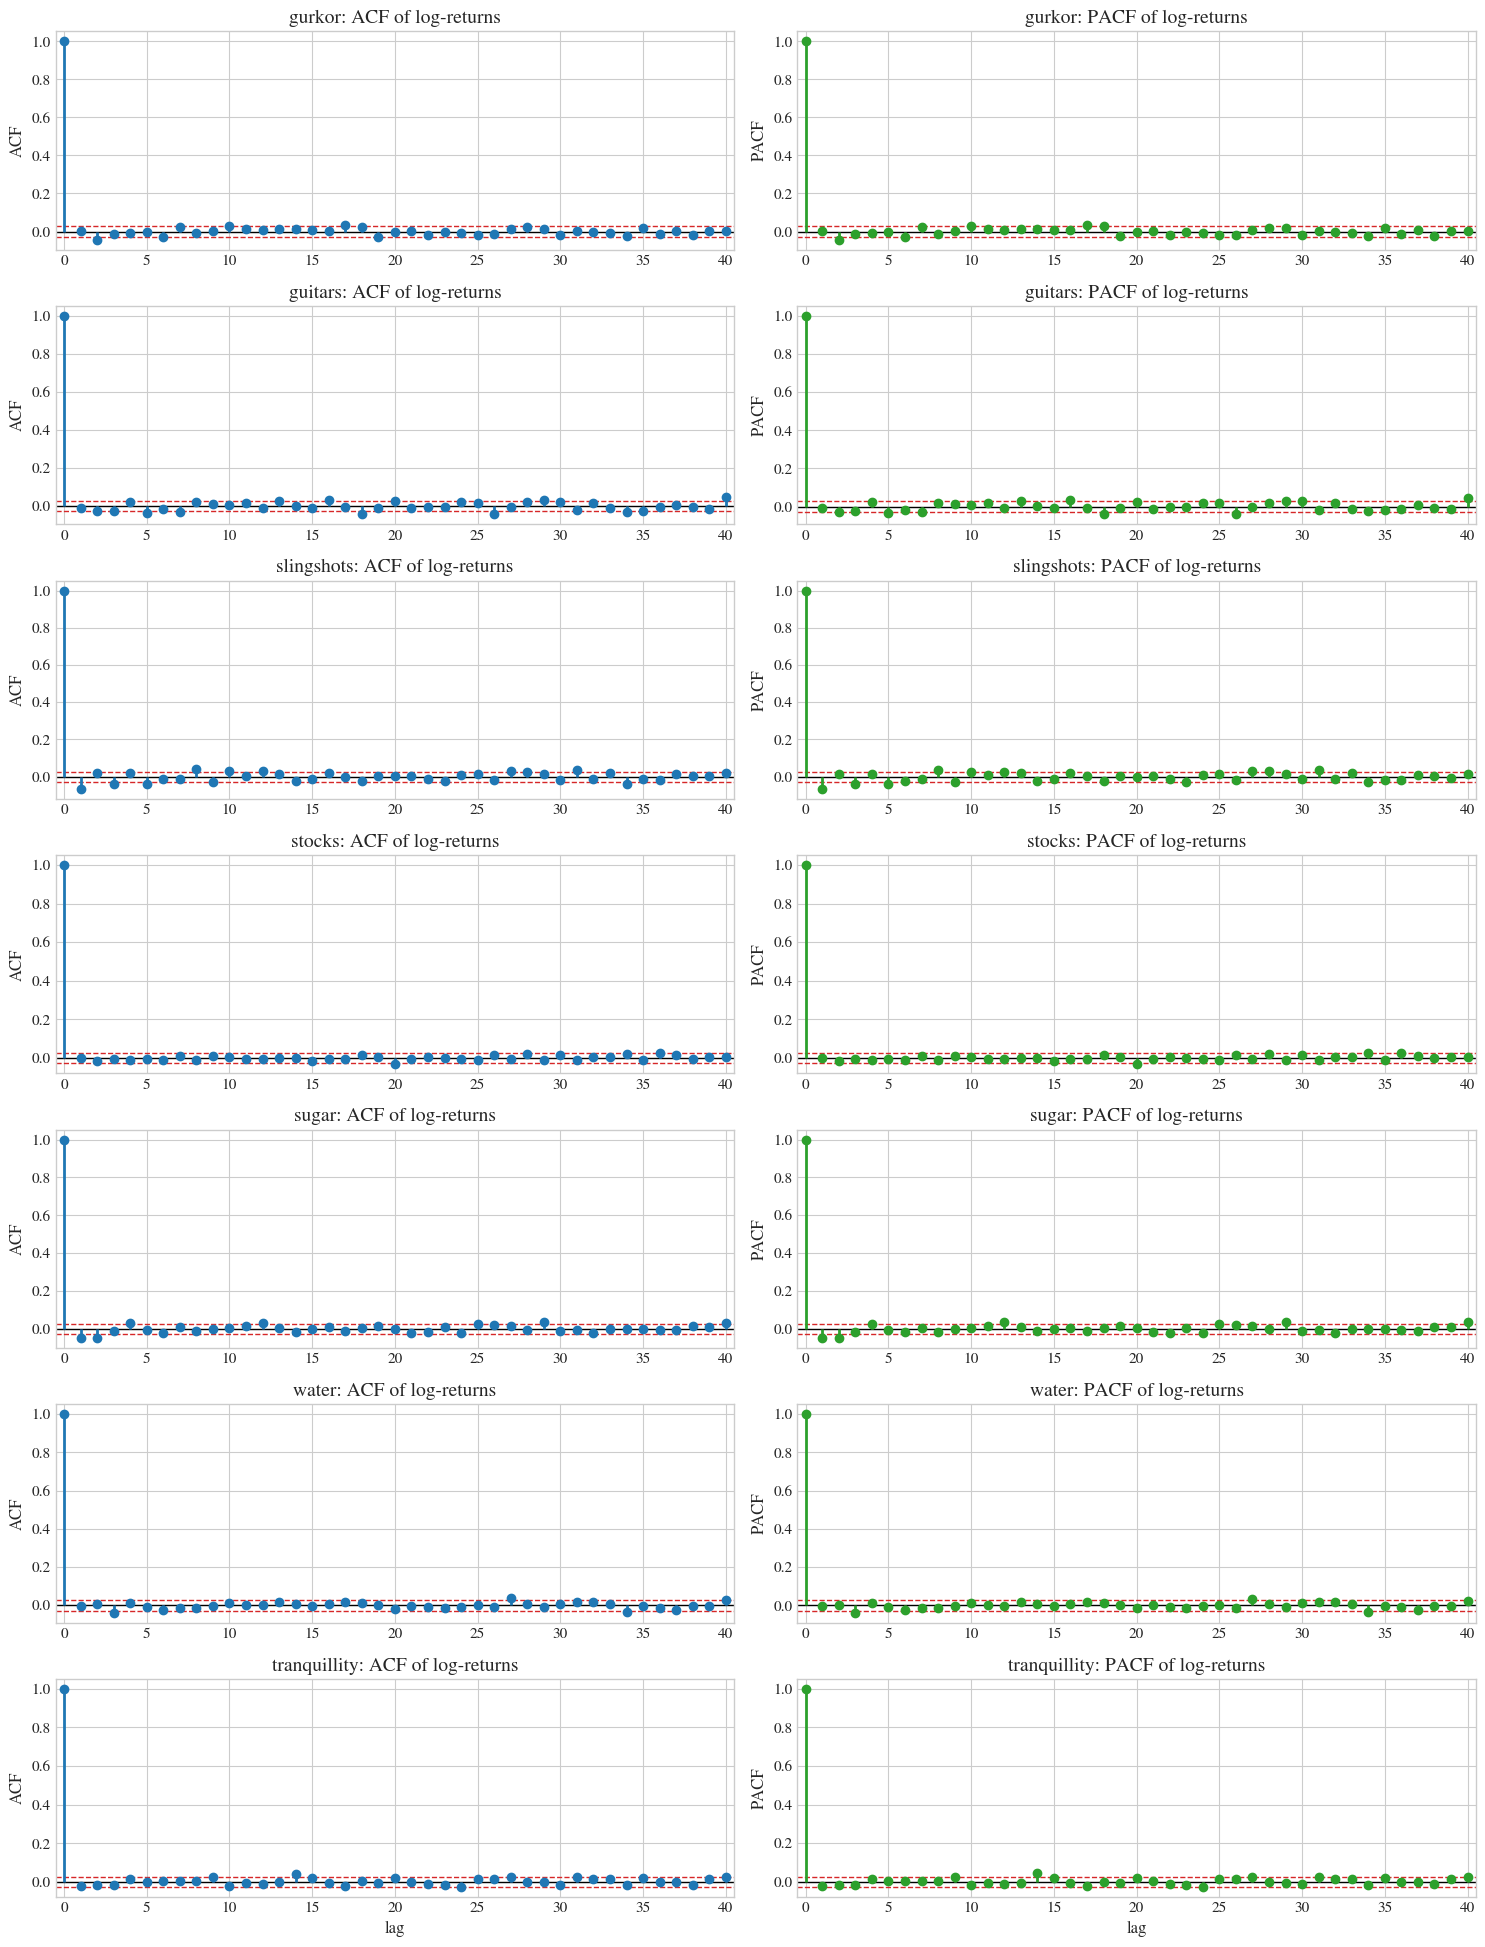

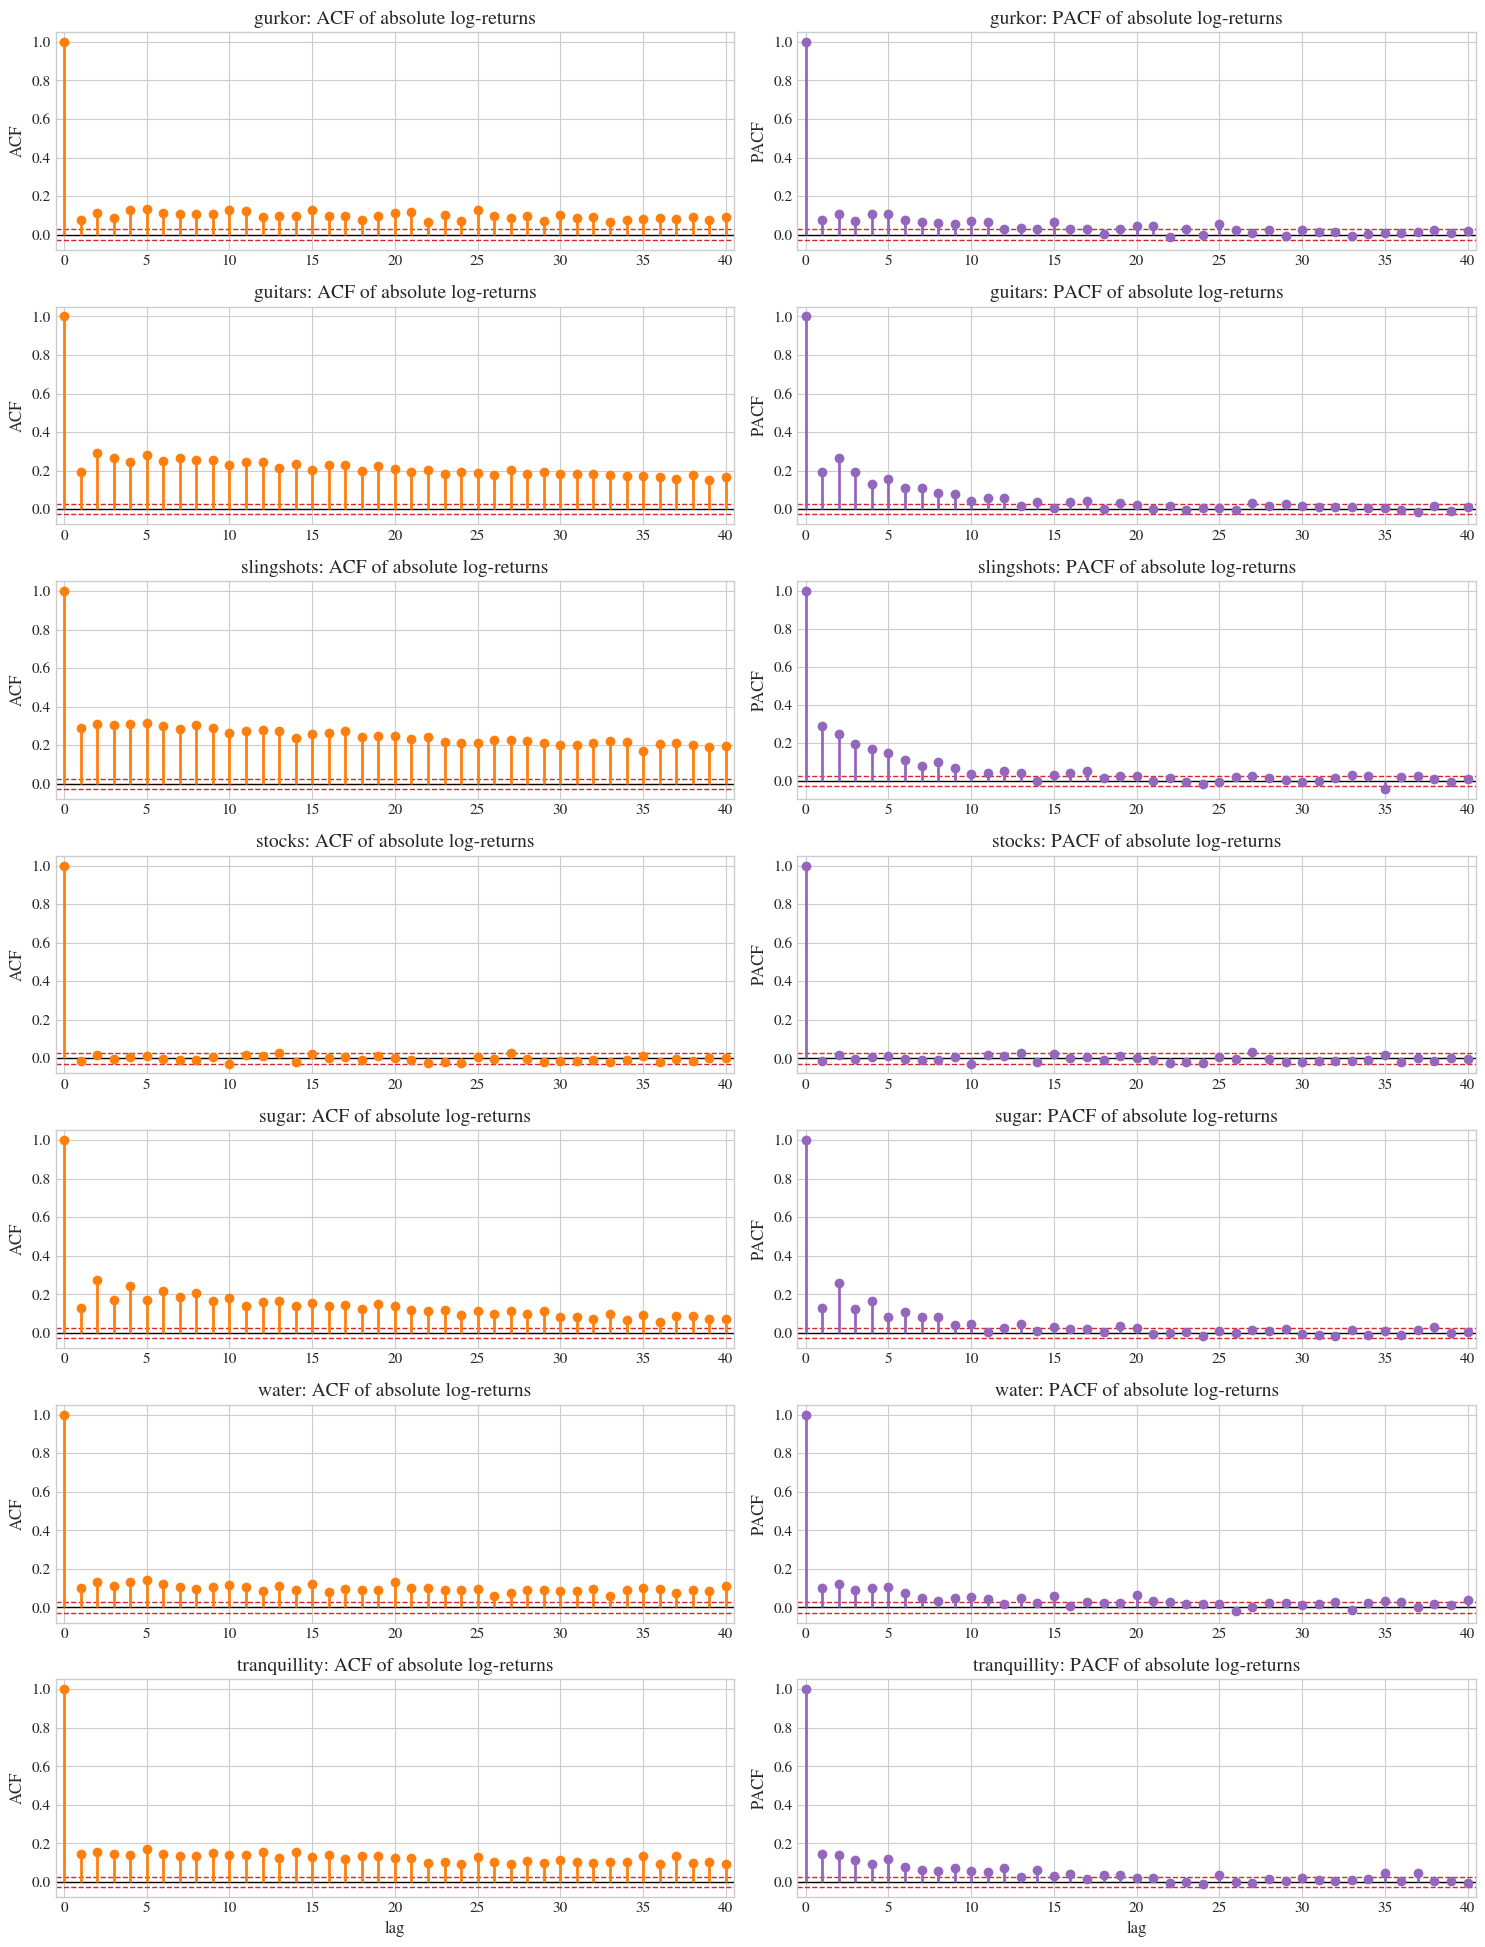

In [49]:
max_lag = 40
plot_dual_serial_correlation_grid(
    log_return_data,
    cleaned_data,
    max_lag=max_lag,
    label="log-returns",
    acf_color="tab:blue",
    pacf_color="tab:green",
)

plot_dual_serial_correlation_grid(
    absolute_log_return_data,
    cleaned_data,
    max_lag=max_lag,
    label="absolute log-returns",
    acf_color="tab:orange",
    pacf_color="tab:purple",
)


### Ljung--Box tests on transformed returns

The Ljung--Box (LB) test is a portmanteau test for autocorrelation. Instead of looking at one lag at a time, it checks whether the autocorrelations up to some chosen lag horizon are jointly equal to zero. In other words, it tests whether the series behaves like white noise over the first $h$ lags.

For a sample of size $T$, the test statistic at lag horizon $h$ is

$$
Q(h) = T(T+2) \sum_{k=1}^h \frac{\hat\rho_k^2}{T-k},
$$

where $\hat\rho_k$ is the sample autocorrelation at lag $k$.

The null hypothesis is that there is no autocorrelation up to lag $h$. A large test statistic and a small p-value provide evidence against this null hypothesis. Therefore:

- a **large p-value** means the data are consistent with no serial correlation up to lag $h$,
- a **small p-value** means the series shows significant serial dependence over that range of lags.

We apply the LB test to three transformations of returns:

- $r_t$: to detect linear dependence in returns,
- $|r_t|$: to detect dependence in return magnitudes,
- $r_t^2$: to detect dependence in volatility-related dynamics.

The last two transformations are especially useful for identifying **volatility clustering**. Thus, even if raw returns appear uncorrelated, significant LB test results for $|r_t|$ or $r_t^2$ indicate that the variance is not constant over time.

In [50]:
ljung_box_returns = cleaned_data.ljung_box_summary(log_return_data)
ljung_box_absolute_returns = cleaned_data.ljung_box_summary(absolute_log_return_data)
ljung_box_squared_returns = cleaned_data.ljung_box_summary(squared_log_return_data)

ljung_box_table = pd.concat(
    [
        ljung_box_returns.add_prefix("log_return_"),
        ljung_box_absolute_returns.add_prefix("abs_log_return_"),
        ljung_box_squared_returns.add_prefix("sq_log_return_"),
    ],
    axis=1,
)

ljung_box_display = ljung_box_table.reset_index()
ljung_box_conclusions = ljung_box_conclusion_table(ljung_box_table)

display(ljung_box_display.round(5))
display(ljung_box_conclusions)
ljung_box_display.to_latex(output / "LjungBox.tex", index=False, float_format=lambda value: f"{value:.3g}")
ljung_box_conclusions.to_latex(output / "LjungBoxConclusions.tex", index=False)


,series,log_return_lb_stat_lag_10,log_return_lb_pvalue_lag_10,log_return_lb_stat_lag_20,log_return_lb_pvalue_lag_20,abs_log_return_lb_stat_lag_10,abs_log_return_lb_pvalue_lag_10,abs_log_return_lb_stat_lag_20,abs_log_return_lb_pvalue_lag_20,sq_log_return_lb_stat_lag_10,sq_log_return_lb_pvalue_lag_10,sq_log_return_lb_stat_lag_20,sq_log_return_lb_pvalue_lag_20
0,gurkor,24.29228,0.00686,41.82123,0.00292,638.04034,0.00000,1196.45511,0.00000,364.34342,0.00000,699.34549,0.00000
1,guitars,24.79240,0.00575,50.26212,0.00020,3368.43098,0.00000,5957.25552,0.00000,2067.53863,0.00000,3816.19873,0.00000
2,slingshots,64.07261,0.00000,78.16911,0.00000,4610.62175,0.00000,8151.39581,0.00000,4827.40625,0.00000,8173.36331,0.00000
3,stocks,4.26679,0.93451,12.47630,0.89871,8.04220,0.62471,21.36552,0.37591,7.15698,0.71055,17.74669,0.60409
4,sugar,33.06883,0.00027,43.07193,0.00200,2056.09224,0.00000,3169.43652,0.00000,3928.03680,0.00000,4921.06974,0.00000
5,water,15.46807,0.11591,22.07705,0.33634,720.78700,0.00000,1258.78968,0.00000,465.35855,0.00000,845.87589,0.00000
6,tranquillity,11.90319,0.29159,31.02201,0.05490,1131.18169,0.00000,2106.58357,0.00000,661.90849,0.00000,1255.53884,0.00000


,series,returns,absolute_returns,squared_returns,overall_conclusion
0,gurkor,"Reject at lags 10, 20","Reject at lags 10, 20","Reject at lags 10, 20",Linear dependence + volatility clustering
1,guitars,"Reject at lags 10, 20","Reject at lags 10, 20","Reject at lags 10, 20",Linear dependence + volatility clustering
2,slingshots,"Reject at lags 10, 20","Reject at lags 10, 20","Reject at lags 10, 20",Linear dependence + volatility clustering
3,stocks,No rejection,No rejection,No rejection,No clear serial dependence
4,sugar,"Reject at lags 10, 20","Reject at lags 10, 20","Reject at lags 10, 20",Linear dependence + volatility clustering
5,water,No rejection,"Reject at lags 10, 20","Reject at lags 10, 20",Volatility clustering only
6,tranquillity,No rejection,"Reject at lags 10, 20","Reject at lags 10, 20",Volatility clustering only



- **Returns $r_t$** show significant autocorrelation for **gurkor, guitars, slingshots, and sugar**, while **stocks, water, and tranquillity** show weak or no evidence of linear dependence.
- **Absolute returns $|r_t|$** and **squared returns $r_t^2$** are highly significant for all series except **stocks**.
- This suggests strong **volatility clustering** in **gurkor, guitars, slingshots, sugar, water, and tranquillity**.
- **Stocks** is the only series that looks approximately like white noise in both returns and volatility.
- Overall, several series show little predictability in returns themselves, but clear persistence in the size of returns, which is consistent with conditional heteroskedasticity.

## 7. Seasonality and trend

# TODO: Improve

## 8. Cross-series relationships

Task 1 also asks what relationships exist between the different assets. We compare price-level and return correlations, identify strongest and weakest return pairs, and then test whether broader groups are stable enough to be useful.


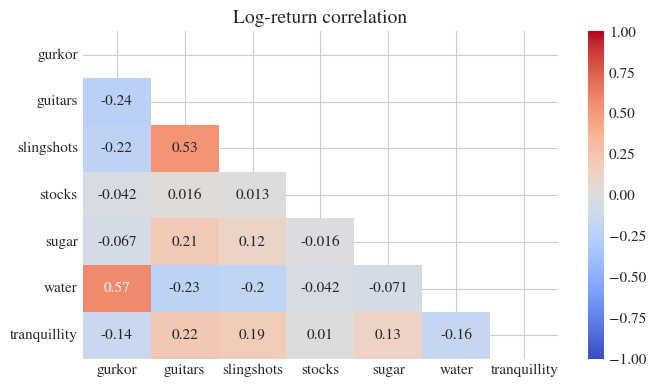

In [51]:
return_correlation_matrix = log_return_data.corr()

fig, axes = plt.subplots()
mask = np.triu(np.ones_like(return_correlation_matrix, dtype=bool), k=0)


sns.heatmap(return_correlation_matrix, annot=True, cmap="coolwarm", center=0,vmin=-1,vmax=1, mask=mask)
axes.set_title("Log-return correlation")

plt.tight_layout()
plt.savefig(output / "correlation_heatmaps.png", bbox_inches="tight")
plt.show()


### Grouping assets by log-return correlation

A simple first-pass grouping rule is to connect assets whenever their log-return correlation exceeds a chosen threshold. The threshold is not a law of nature, but it makes the grouping assumption explicit and easy to critique.


In [52]:
return_correlation_groups = cleaned_data.correlation_groups(log_return_data, threshold=0.3)
groups_only = (
    return_correlation_groups
    .reset_index()
    .drop_duplicates(subset="group")
    [["group_members", "group_size", "avg_within_group_correlation"]]
    .reset_index(drop=True)
)

display(groups_only)


,group_members,group_size,avg_within_group_correlation
0,"guitars, slingshots",2,0.526253
1,"gurkor, water",2,0.573293
2,stocks,1,NaN
3,sugar,1,NaN
4,tranquillity,1,NaN


### Dendrogram of asset similarity

To visualize the grouping more continuously, we also build a hierarchical clustering tree from the log-return correlations using the distance

$$
d_{ij} = 1 - \hat\rho_{ij}.
$$

Assets that merge at a low height are more similar. The lowest merges are the most informative; all assets eventually join the same tree at higher levels, so shared high branches should not be over-interpreted.


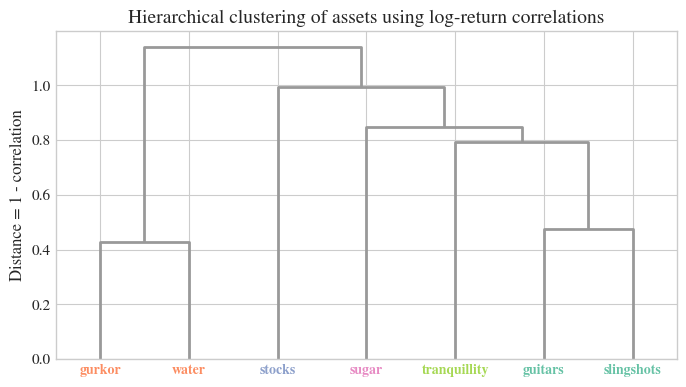

In [53]:
distance_matrix = (1 - return_correlation_matrix).clip(lower=0)
distance_array = distance_matrix.to_numpy(copy=True)
np.fill_diagonal(distance_array, 0.0)
condensed_distance = squareform(distance_array, checks=False)
linkage_matrix = linkage(condensed_distance, method="average")

group_ids = return_correlation_groups["group"].unique()
group_palette = sns.color_palette("Set2", n_colors=len(group_ids))
group_colors = dict(zip(group_ids, group_palette))
label_colors = {asset: group_colors[return_correlation_groups.loc[asset, "group"]] for asset in return_correlation_groups.index}

fig, ax = plt.subplots()
dendrogram(
    linkage_matrix,
    labels=return_correlation_matrix.index.tolist(),
    leaf_rotation=0,
    leaf_font_size=10,
    color_threshold=0,
    above_threshold_color="0.6",
    ax=ax,
)

for tick in ax.get_xmajorticklabels():
    tick.set_color(label_colors[tick.get_text()])
    tick.set_fontweight("bold")

ax.set_title("Hierarchical clustering of assets using log-return correlations")
ax.set_ylabel("Distance = 1 - correlation")
plt.tight_layout()
plt.savefig(output / "return_correlation_dendrogram.png", bbox_inches="tight")
plt.show()


## 9. Time-varying relationships and grouping robustness

Static correlations are averages over the whole sample. Rolling correlations check whether those relationships remain stable or whether the grouping changes over time.


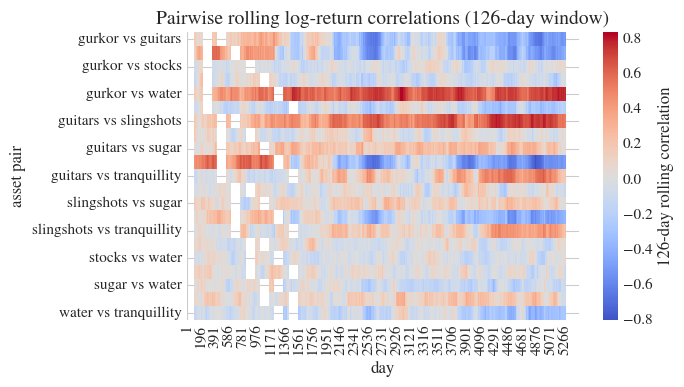

In [54]:
rolling_corr_window = 126
rolling_corr_min_periods = int(0.8 * rolling_corr_window)
rolling_pair_corrs = rolling_pairwise_correlations(
    log_return_data,
    window=rolling_corr_window,
    min_periods=rolling_corr_min_periods,
)

fig, ax = plt.subplots()
sns.heatmap(
    rolling_pair_corrs.T,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": f"{rolling_corr_window}-day rolling correlation"},
    ax=ax,
)
ax.set_title(f"Pairwise rolling log-return correlations ({rolling_corr_window}-day window)")
ax.set_xlabel("day")
ax.set_ylabel("asset pair")
plt.tight_layout()
plt.savefig(output / "rolling_pair_correlations_126.png", bbox_inches="tight")
plt.show()


The rolling-correlation summary below answers the grouping-stability question directly: how often does each pair stay above the same positive-correlation threshold used for the static correlation grouping? It also reports variability, endpoint change, and the share of windows with strong absolute correlation so negative relationships are not hidden.


In [55]:
correlation_group_threshold = 0.3
rolling_corr_summary = rolling_correlation_stability_summary(
    rolling_pair_corrs,
    threshold=correlation_group_threshold,
)
threshold_label = str(correlation_group_threshold).replace(".", "_")
positive_share_col = f"share_corr_ge_{threshold_label}"
negative_share_col = f"share_corr_le_minus_{threshold_label}"
absolute_share_col = f"share_abs_corr_ge_{threshold_label}"
stability_columns = [
    "pair",
    "n_windows",
    "mean",
    "std",
    "min",
    "max",
    positive_share_col,
    negative_share_col,
    absolute_share_col,
    "abs_change",
]

#display(rolling_corr_summary[stability_columns].round(3))


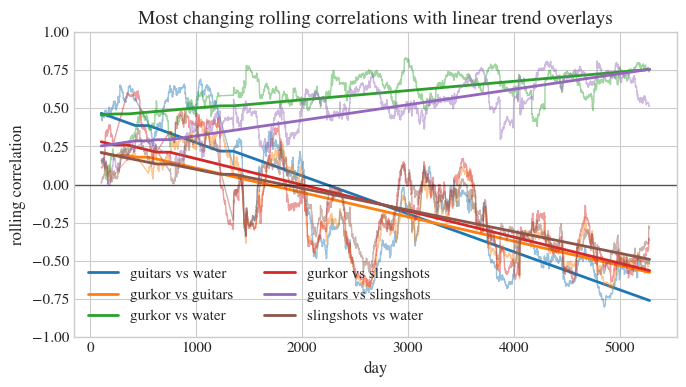

In [56]:
top_changing_pairs = rolling_corr_summary.sort_values("abs_change", ascending=False).head(6)["pair"].tolist()

fig, ax = plt.subplots()
for pair_name in top_changing_pairs:
    y = rolling_pair_corrs[pair_name].dropna()
    x = np.arange(len(y))
    line, = ax.plot(y.index, y.to_numpy(), lw=1, alpha=0.45)

    if len(y) > 1:
        slope, intercept = np.polyfit(x, y.to_numpy(), 1)
        ax.plot(y.index, slope * x + intercept, lw=2, label=pair_name, color=line.get_color())

ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.set_ylim(-1, 1)
ax.set_xlabel("day")
ax.set_ylabel("rolling correlation")
ax.set_title("Most changing rolling correlations with linear trend overlays")
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(output / "rolling_pair_correlations_top_changes.png", bbox_inches="tight")
plt.show()


Several correlations move substantially over time. The threshold-share columns are therefore more useful than a single full-sample correlation: they show whether a pair would repeatedly pass the grouping rule, not just whether its average is high. Pairs with high threshold shares are stable candidates for grouping; pairs with large `abs_change` but low threshold shares are time-varying relationships rather than stable groups.


### Clustering setup: what is being clustered

The clustering below groups **assets**, not days. Each row is one asset, and the columns describe that asset from one specific angle.

We use three views:

- **Distribution features**: group assets with similar return distributions and volatility behavior.
- **Correlation profiles**: compare how each asset relates to the other assets.
- **PCA return paths**: group assets whose standardized return paths move similarly over time.

Cluster numbers are arbitrary labels. We use the silhouette table only as a separation diagnostic; if a simpler split scores better, the finer split is exploratory.


### Clustering view 1: distribution features

Here we cluster assets by their own return-distribution features: mean, volatility, skewness, kurtosis, quantiles, and short-lag dependence in absolute and squared returns.

We are looking for assets with similar marginal distributions and volatility-clustering behavior. This view does **not** ask whether two assets move together.


Groups based on return behavior features:
Cluster 0: ['sugar', 'tranquillity']
Cluster 1: ['gurkor', 'water']
Cluster 2: ['guitars', 'slingshots']
Cluster 3: ['stocks']


,n_clusters,silhouette_score
0,2,0.340
1,3,0.339
2,4,0.277
3,5,0.272


,cluster_return_features,mean,volatility,skewness,excess_kurtosis,q05,q95,abs_return_acf_lag_5,sq_return_acf_lag_5
tranquillity,0,0.00008,0.01228,-0.27862,3.27794,-0.01886,0.01993,0.17090,0.13926
sugar,0,-0.00001,0.01484,-0.24453,11.39579,-0.02321,0.02241,0.17026,0.11428
water,1,0.00015,0.00343,-0.26615,2.51482,-0.00543,0.00558,0.14317,0.10796
gurkor,1,0.00016,0.00385,-0.15064,3.84628,-0.00632,0.00616,0.13449,0.09267
slingshots,2,0.00019,0.01439,-0.45607,6.91453,-0.02250,0.02096,0.31408,0.34213
guitars,2,0.00024,0.01451,-0.03581,5.99020,-0.02360,0.02154,0.28028,0.24369
stocks,3,-0.00007,0.01457,-0.12730,0.23248,-0.02481,0.02350,0.00995,0.00835


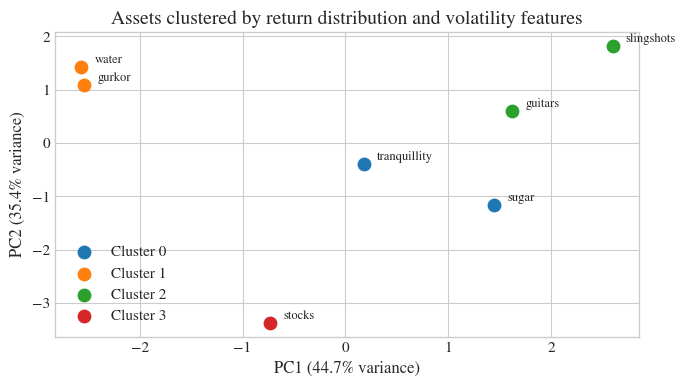

In [57]:
return_data_filled = fill_missing_with_series_mean(log_return_data)
feature_df = build_return_feature_table(
    return_data_filled,
    absolute_log_return_data,
    squared_log_return_data,
    cleaned_data,
    acf_lag=5,
)

feature_cluster = run_asset_clustering(
    feature_df,
    n_clusters=4,
    cluster_col="cluster_return_features",
    scale_columns=True,
)
X_stats = feature_cluster["model_values"]
feature_cluster_table = feature_cluster["assignments"].join(feature_df)

print_cluster_groups(feature_cluster["groups"], "Groups based on return behavior features:")
display(feature_cluster["silhouette_scores"].round(3))
display(feature_cluster_table.sort_values(["cluster_return_features", "volatility"]).round(5))

X_stats_2d, pca_stats = plot_pca_projection(
    feature_cluster,
    "Assets clustered by return distribution and volatility features",
    output / "log_return_feature_clustering_pca.png",
)


Small changes in the ACF-lag feature can move borderline assets between groups, so the detailed split should be interpreted cautiously.

### Clustering view 2: correlation profiles

Here we create one profile per asset: its correlations with all the other assets. This asks whether two assets have a similar role relative to the rest of the system.

This is different from direct pairwise correlation. It can show broader relationship patterns, but with only seven assets it is sensitive to outliers, so we treat it as exploratory.


Groups based on correlation profiles:
Cluster 0: ['guitars']
Cluster 1: ['slingshots', 'stocks', 'sugar', 'tranquillity']
Cluster 2: ['gurkor', 'water']


,n_clusters,silhouette_score
0,2,0.443
1,3,0.274
2,4,0.185
3,5,0.140


,cluster_corr,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
guitars,0,-0.241,0.000,0.526,0.016,0.212,-0.226,0.224
slingshots,1,-0.217,0.526,0.000,0.013,0.118,-0.201,0.189
stocks,1,-0.042,0.016,0.013,0.000,-0.016,-0.042,0.010
sugar,1,-0.067,0.212,0.118,-0.016,0.000,-0.071,0.127
tranquillity,1,-0.138,0.224,0.189,0.010,0.127,-0.158,0.000
gurkor,2,0.000,-0.241,-0.217,-0.042,-0.067,0.573,-0.138
water,2,0.573,-0.226,-0.201,-0.042,-0.071,0.000,-0.158


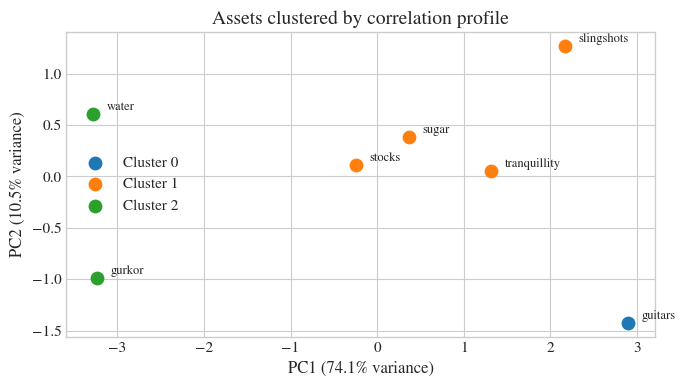

In [58]:
corr_profile_df = remove_self_correlations(return_correlation_matrix)
corr_cluster = run_asset_clustering(
    corr_profile_df,
    n_clusters=3,
    cluster_col="cluster_corr",
    scale_columns=True,
)
X_corr = corr_cluster["model_values"]
corr_groups_df = corr_cluster["assignments"]

print_cluster_groups(corr_cluster["groups"], "Groups based on correlation profiles:")
display(corr_cluster["silhouette_scores"].round(3))
display(corr_groups_df.join(corr_profile_df).sort_values("cluster_corr").round(3))

X_corr_2d, pca_corr = plot_pca_projection(
    corr_cluster,
    "Assets clustered by correlation profile",
    output / "log_return_correlation_profile_pca.png",
)


### Clustering view 3: PCA of standardized return paths

Here we cluster assets based on their full return paths. Each asset's returns are standardized first, so the clustering focuses on timing and shape rather than average level or volatility scale.

We then use PCA to reduce the standardized return paths and cluster the PCA scores. We are looking for assets that move through similar return regimes over time.


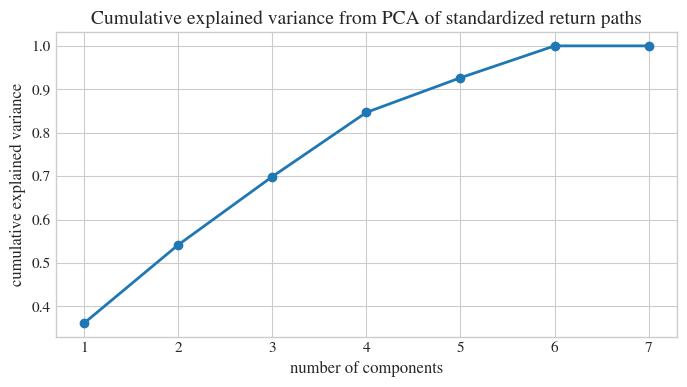

Groups based on PCA of standardized return paths:
Cluster 0: ['guitars', 'slingshots']
Cluster 1: ['gurkor', 'water']
Cluster 2: ['stocks']
Cluster 3: ['sugar', 'tranquillity']


,n_clusters,silhouette_score
0,2,0.205
1,3,0.174
2,4,0.160
3,5,0.167


,cluster_pca,path_pc_1,path_pc_2
guitars,0,43.336,-12.432
slingshots,0,40.220,-10.612
gurkor,1,-60.159,-12.190
water,1,-59.635,-12.681
stocks,2,-2.757,69.275
sugar,3,14.378,-18.833
tranquillity,3,24.617,-2.527


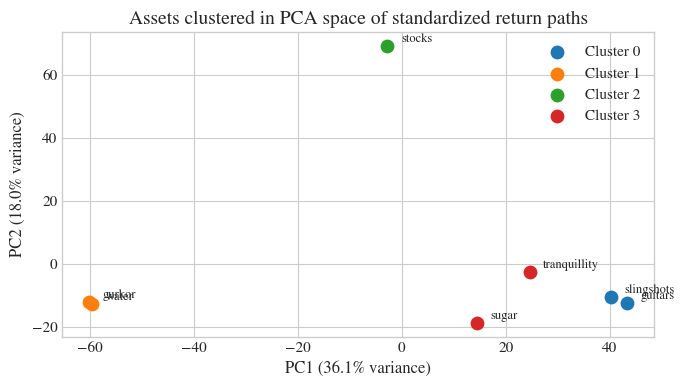

In [59]:
path_pc_df, pca_ts, X_ts_scaled = standardized_return_path_pca(return_data_filled, n_components=7)
X_pca = path_pc_df.to_numpy()

plot_cumulative_explained_variance(
    pca_ts,
    "Cumulative explained variance from PCA of standardized return paths",
    output / "log_return_path_pca_explained_variance.png",
)

path_cluster = run_asset_clustering(
    path_pc_df,
    n_clusters=4,
    cluster_col="cluster_pca",
    scale_columns=False,
)
pca_groups_df = path_cluster["assignments"]
groups_pca = path_cluster["groups"]

print_cluster_groups(groups_pca, "Groups based on PCA of standardized return paths:")
display(path_cluster["silhouette_scores"].round(3))
display(pca_groups_df.join(path_pc_df.iloc[:, :2]).sort_values("cluster_pca").round(3))

plot_cluster_scatter(
    X_pca[:, :2],
    pca_ts.explained_variance_ratio_[:2],
    pca_groups_df,
    "cluster_pca",
    "Assets clustered in PCA space of standardized return paths",
    output / "log_return_path_clustering_pca.png",
)


### Rolling correlation-threshold stability

How often does each pair have a rolling correlation above the grouping threshold?

Values near 1 mean the pair repeatedly satisfies the positive-correlation grouping rule. Values near 0 mean the pair rarely looks like a stable positive group in rolling windows. This avoids the correlation-profile artifact where an outlier asset or a swapped coordinate can distort the clustering distance.


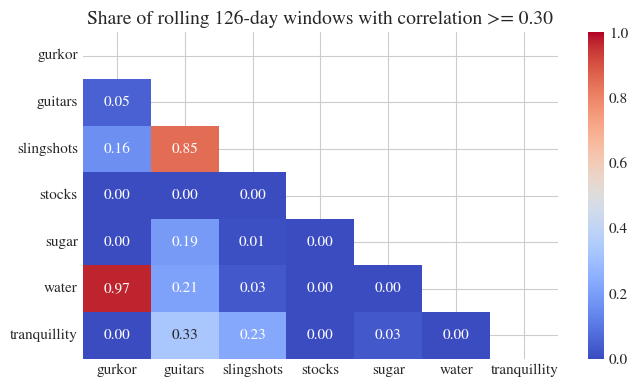

In [60]:
positive_stability_matrix = rolling_correlation_stability_matrix(
    rolling_corr_summary,
    value_col=positive_share_col,
    assets=log_return_data.columns,
)

plot_pairwise_stability_heatmap(
    positive_stability_matrix,
    f"Share of rolling {rolling_corr_window}-day windows with correlation >= {correlation_group_threshold:.2f}",
    output / "rolling_positive_correlation_stability.png",
)



Overall, the clustering supports approximate relationships rather than fixed asset classes. The clearest pair-based evidence comes from direct correlations and rolling threshold stability, especially `{gurkor, water}` and `{guitars, slingshots}`.

`stocks` is usually isolated. `sugar` and `tranquillity` are less stable and attach differently depending on whether we look at distributions, correlation profiles, or return paths.


## 10. Volatility regimes

The Ljung--Box and ACF/PACF results tell us that volatility clustering is present. Here we make that more concrete by classifying each observed day into a volatility regime.

A regime should be persistent. We therefore use two steps: first fit Gaussian mixture models to each asset's **log 63-day rolling volatility**, with BIC choosing whether one, two, or three volatility levels are supported; then merge short spells shorter than 21 trading days into neighboring regimes.

This avoids two problems: regime sizes are not forced to be one third each, and brief boundary flickers are not treated as real volatility regimes.


In [61]:
volatility_regime_window = 126
volatility_regime_min_periods = int(0.8 * volatility_regime_window)
volatility_regime_method = "gmm"
volatility_regime_min_spell_length = 63
regime_assets = [asset for asset in log_return_data.columns if asset != "stocks"]

volatility_regime_result = classify_volatility_regimes(
    log_return_data[regime_assets],
    window=volatility_regime_window,
    min_periods=volatility_regime_min_periods,
    method=volatility_regime_method,
    min_spell_length=volatility_regime_min_spell_length,
)

rolling_volatility = volatility_regime_result["rolling_volatility"]
volatility_regimes = volatility_regime_result["regimes"]
volatility_regime_thresholds = volatility_regime_result["thresholds"]

display(volatility_regime_thresholds.round(6))


,low_medium_threshold,medium_high_threshold,low_center,medium_center,high_center,n_regimes,n_fitted_regimes,regime_method,min_spell_length,n_short_spells_merged,n_classified_windows
series,,,,,,,,,,,
gurkor,0.003276,0.004491,0.002740,0.003918,0.005147,3,3,gmm,63,17,4996
guitars,0.010274,0.017438,0.008115,0.013008,0.023377,3,3,gmm,63,9,4996
slingshots,0.009407,0.014728,0.007347,0.012044,0.018010,3,3,gmm,63,11,4996
sugar,0.013723,NaN,0.012987,NaN,0.014501,2,2,gmm,63,7,4996
water,0.002976,0.004087,0.002486,0.003562,0.004688,3,3,gmm,63,22,4996
tranquillity,0.010320,0.014372,0.008857,0.012025,0.017177,3,3,gmm,63,30,4996


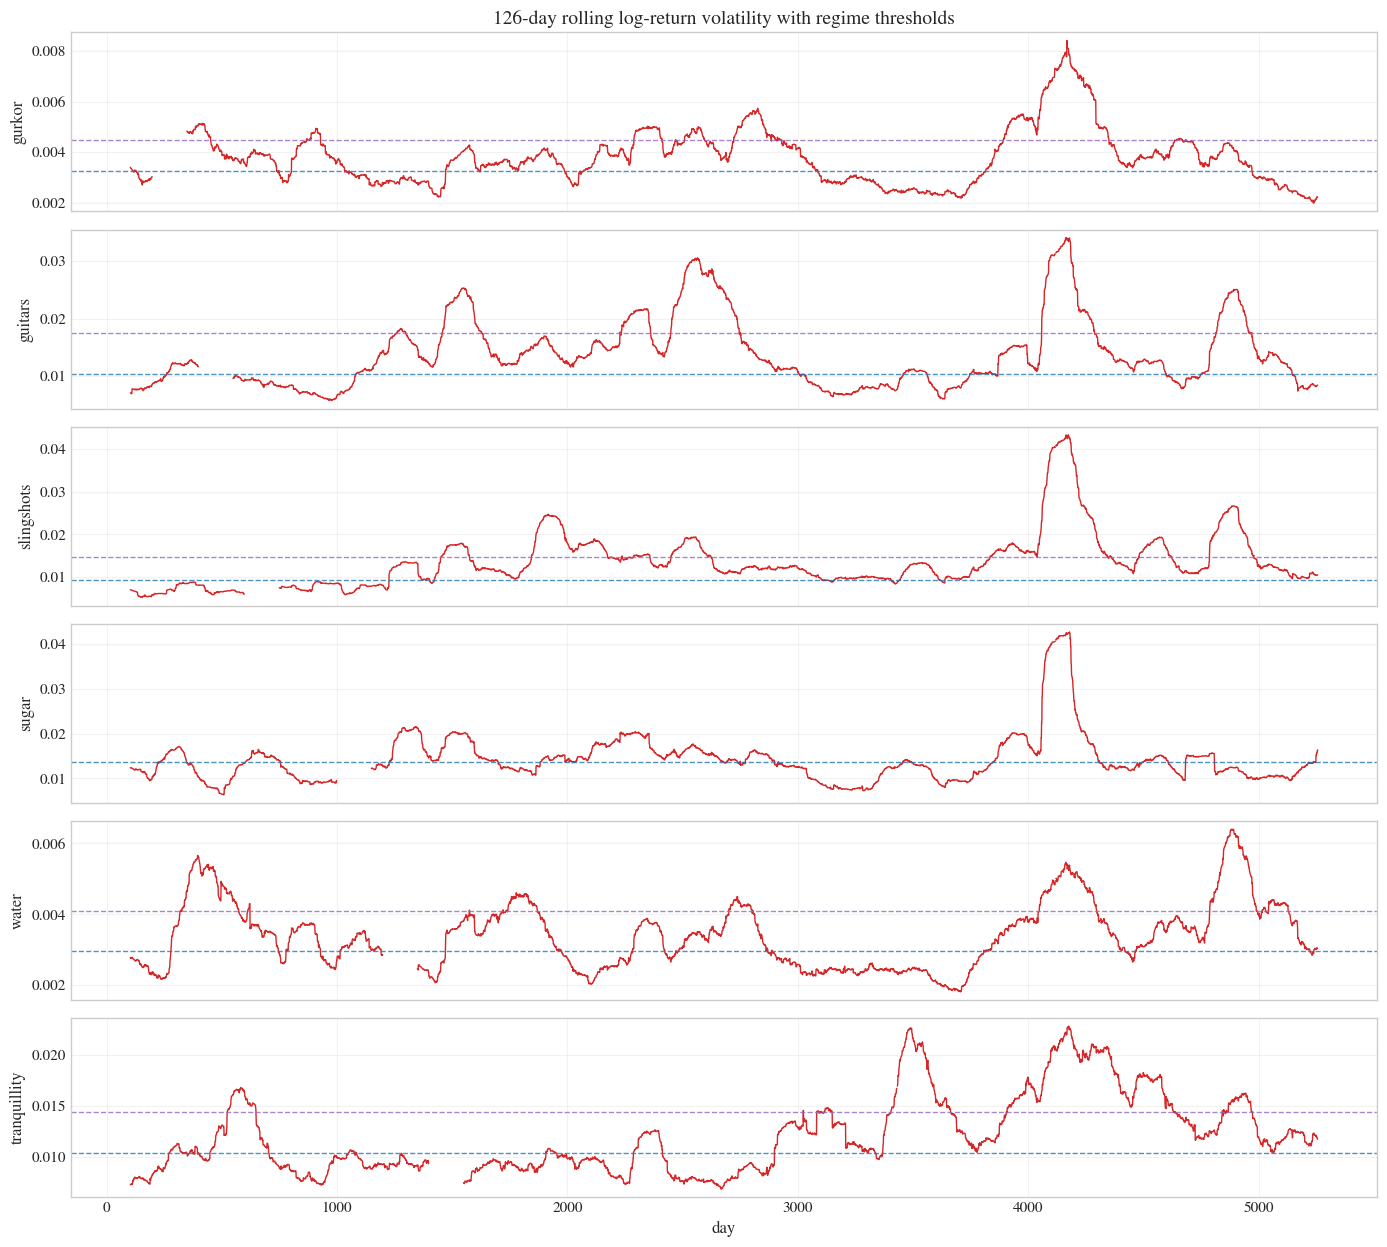

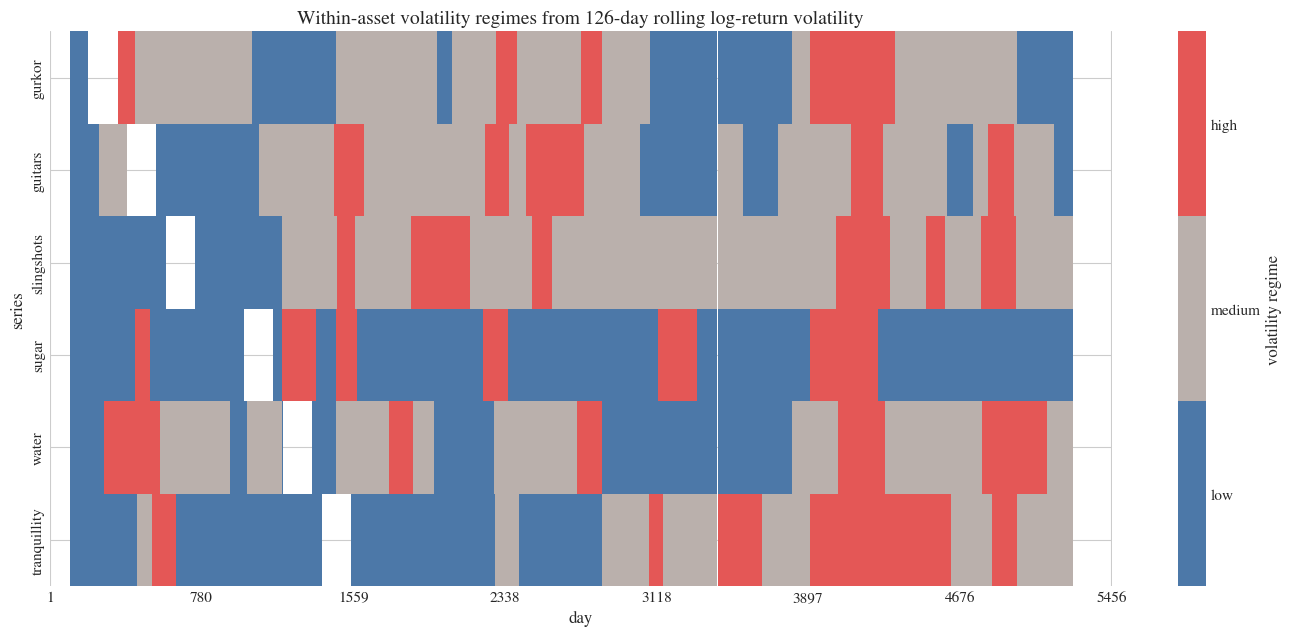

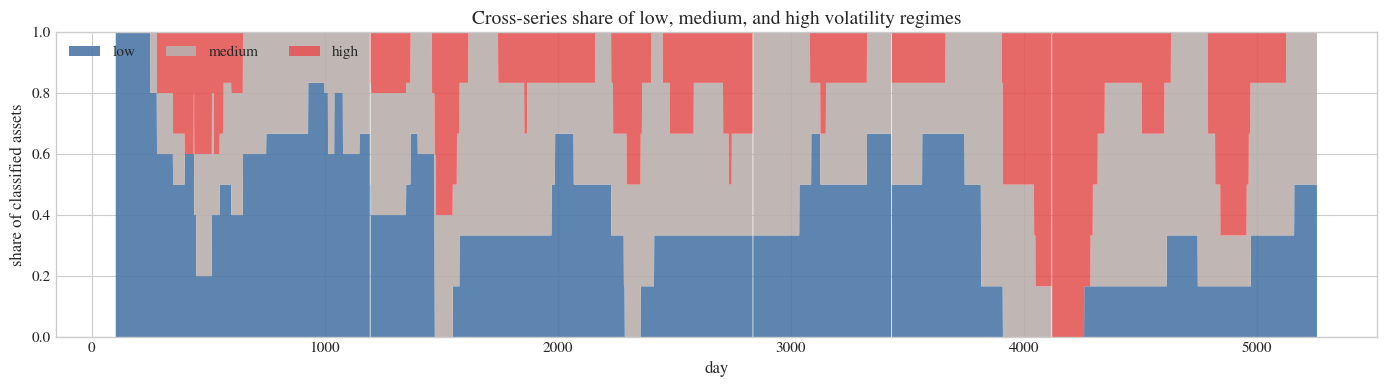

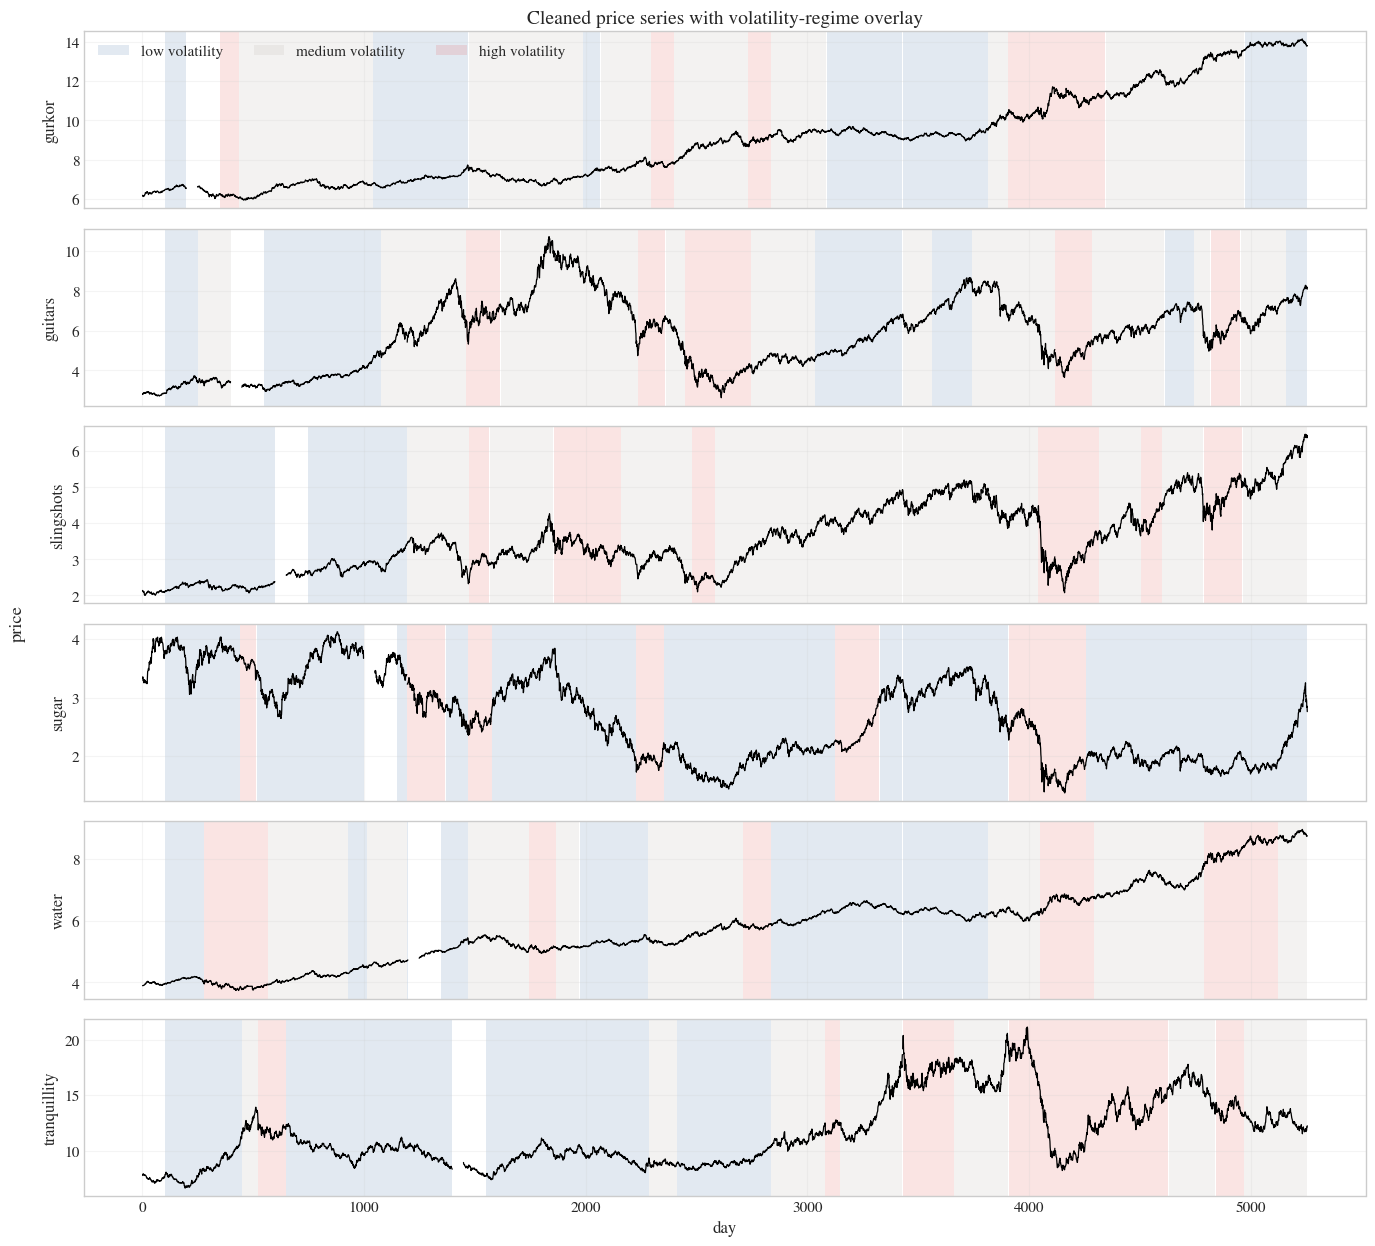

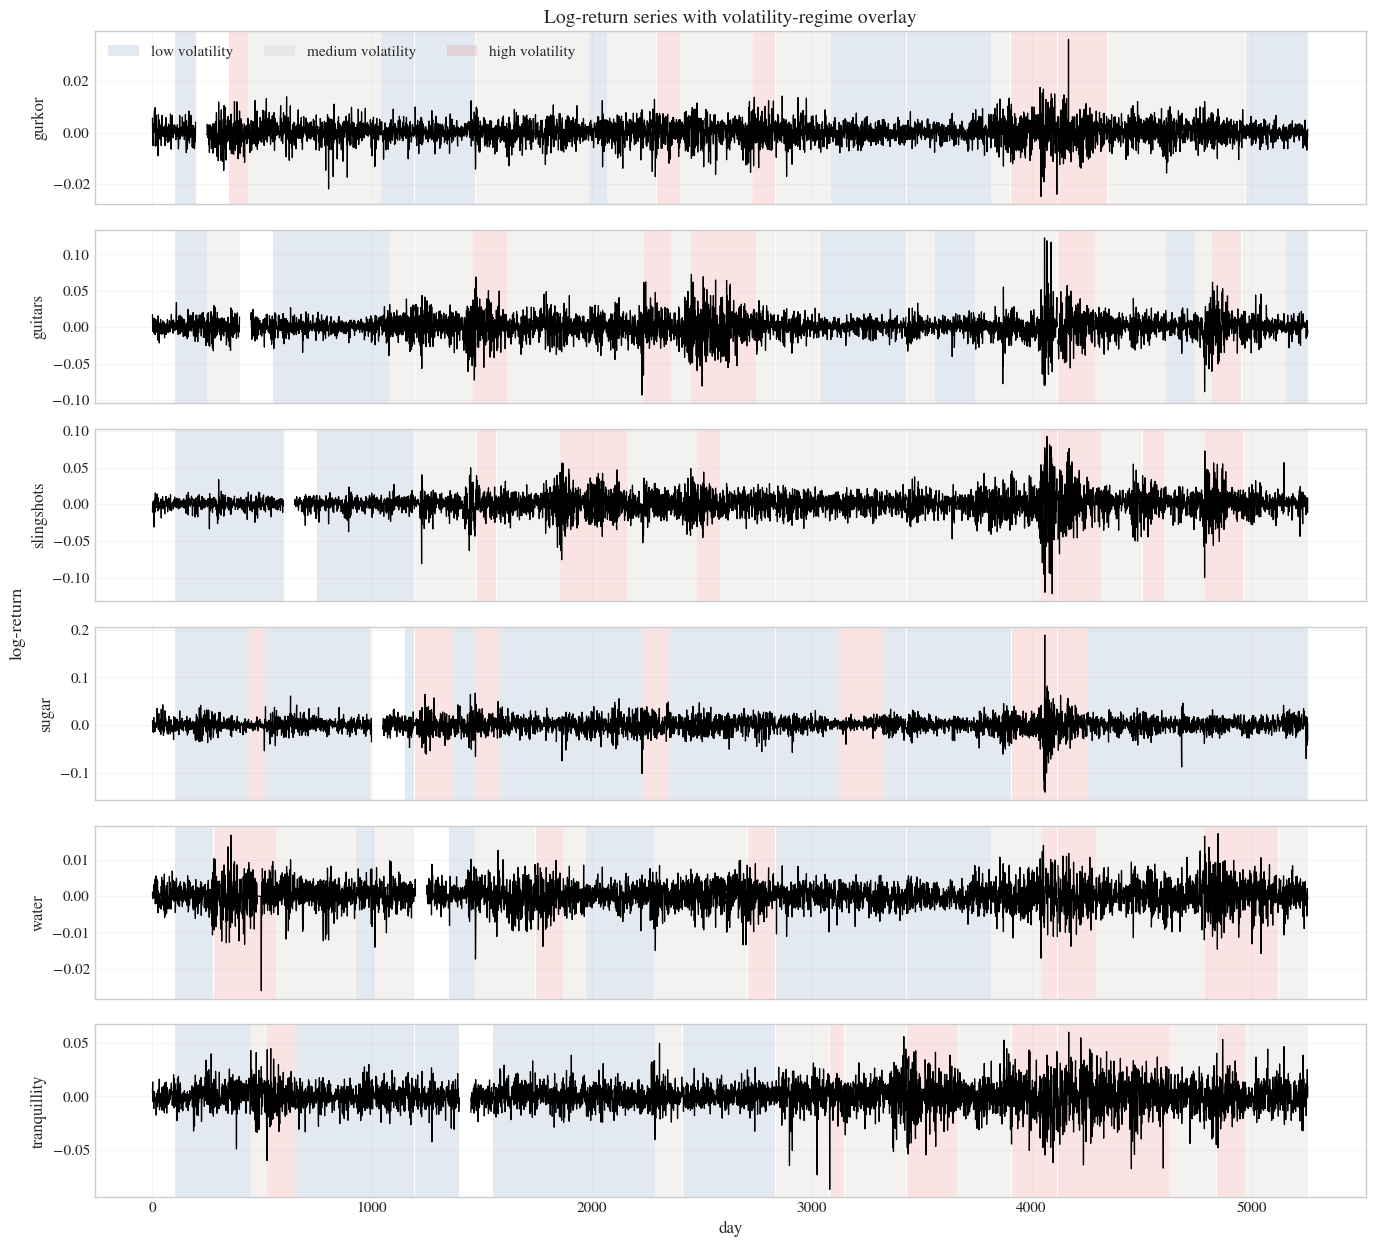

In [62]:
plt.close("all")

plot_rolling_volatility_regimes(
    rolling_volatility,
    volatility_regime_thresholds,
    output / "rolling_volatility_regime_thresholds.png",
    f"{volatility_regime_window}-day rolling log-return volatility with regime thresholds",
)

plot_volatility_regime_heatmap(
    volatility_regimes,
    output / "volatility_regime_heatmap.png",
    f"Within-asset volatility regimes from {volatility_regime_window}-day rolling log-return volatility",
)

volatility_regime_share_table = plot_volatility_regime_shares(
    volatility_regimes,
    output / "volatility_regime_shares.png",
    "Cross-series share of low, medium, and high volatility regimes",
)

plot_series_with_regime_overlay(
    cleaned_prices[volatility_regimes.columns],
    volatility_regimes,
    output / "cleaned_prices_with_volatility_regimes.png",
    "Cleaned price series with volatility-regime overlay",
    "price",
)

plot_series_with_regime_overlay(
    log_return_data[volatility_regimes.columns],
    volatility_regimes,
    output / "log_returns_with_volatility_regimes.png",
    "Log-return series with volatility-regime overlay",
    "log-return",
)


The heatmap shows when each asset is in a relative low, medium, or high volatility regime. The spell table below turns that picture into dated episodes, while the transition summary measures persistence. High persistence and long high-volatility spells are the direct regime-based version of volatility clustering.


In [63]:
volatility_regime_summary = summarize_volatility_regimes(
    volatility_regimes,
    rolling_volatility,
)
volatility_spells = volatility_regime_spells(volatility_regimes)
high_volatility_spells = (
    volatility_spells[volatility_spells["regime"] == "high"]
    .sort_values(["length", "series"], ascending=[False, True])
    .head(12)
    .reset_index(drop=True)
)
volatility_transition_summary = volatility_regime_transition_summary(volatility_regimes)

display(volatility_regime_summary.round(4))
display(high_volatility_spells)
display(volatility_transition_summary.sort_values("same_regime_share", ascending=False).round(4))

volatility_regime_summary.to_latex(output / "VolatilityRegimeSummary.tex", index=False, float_format=lambda value: f"{value:.4g}")
high_volatility_spells.to_latex(output / "HighVolatilitySpells.tex", index=False)
volatility_transition_summary.to_latex(output / "VolatilityRegimeTransitions.tex", index=False, float_format=lambda value: f"{value:.4g}")


,series,regime,n_windows,share_windows,mean_rolling_volatility,median_rolling_volatility,n_spells,avg_spell_length,max_spell_length
0,gurkor,low,1615,0.3233,0.0027,0.0028,7,230.7143,383.0
1,gurkor,medium,2644,0.5292,0.0039,0.0039,7,377.7143,627.0
2,gurkor,high,737,0.1475,0.0057,0.0053,5,147.4000,226.0
3,guitars,low,1485,0.2972,0.0080,0.0080,6,247.5000,529.0
4,guitars,medium,2635,0.5274,0.0136,0.0129,12,219.5833,621.0
5,guitars,high,876,0.1753,0.0242,0.0234,5,175.2000,296.0
6,slingshots,low,941,0.1884,0.0072,0.0070,2,470.5000,496.0
7,slingshots,medium,3013,0.6031,0.0122,0.0120,9,334.7778,611.0
8,slingshots,high,1042,0.2086,0.0230,0.0194,7,148.8571,304.0
9,sugar,low,3968,0.7942,0.0131,0.0131,10,396.8000,999.0


,series,regime,start,end,length
0,tranquillity,high,4120,4629,510
1,water,high,4789,5123,335
2,slingshots,high,1856,2159,304
3,guitars,high,2450,2745,296
4,water,high,280,565,286
5,tranquillity,high,3432,3662,231
6,gurkor,high,4120,4345,226
7,gurkor,high,3905,4117,213
8,sugar,high,3909,4117,209
9,tranquillity,high,3909,4117,209


,series,n_comparable_steps,transition_rate,same_regime_share,low_persistence,medium_persistence,high_persistence
3,sugar,4990,0.0022,0.9978,0.9987,NaN,0.9942
2,slingshots,4990,0.0024,0.9976,1.0000,0.9980,0.9942
5,tranquillity,4990,0.0024,0.9976,0.9991,0.9966,0.9961
0,gurkor,4990,0.0026,0.9974,0.9981,0.9974,0.9959
4,water,4990,0.0030,0.9970,0.9970,0.9973,0.9964
1,guitars,4990,0.0034,0.9966,0.9973,0.9970,0.9943


This regime view should be read as descriptive rather than as a fitted hidden Markov model. It answers: *when is each asset locally calm or turbulent relative to itself?*

The important change from the tertile rule is that regime shares are now an output, not an input. The persistence filter also means a regime must last at least about one trading month before we treat it as meaningful. The `n_short_spells_merged` column reports how many short spells were removed for each asset.

After smoothing, same-regime persistence is around 99.4%--99.6% for the regime-classified assets. `Water` and `tranquillity` are still best described by two regimes, while `sugar` has a relatively small high-volatility regime. These are more defensible regimes than the earlier equal-share split.


## 11. Regime-conditioned correlations

The correlation analysis above averages over the whole sample. Now that we have volatility regimes, we can ask whether correlations are state-dependent.

The calculations below use the assets that have volatility-regime labels in `volatility_regimes`. If `stocks` is excluded from the regime analysis because it does not show clear volatility clustering, it is also excluded from this conditional correlation view.


Because the GMM/BIC classifier can select two regimes for some assets, the pair same-regime table may contain missing medium-regime correlations for pairs involving those assets. The 21-day persistence filter also removes short label flickers before we estimate regime-conditioned correlations.

We use two views:

- **System-volatility view**: average the regime score across the regime-labeled assets, use the same data-driven GMM/BIC idea to classify system calm/turbulent states, then estimate correlations separately in those states.
- **Pair same-regime view**: for each asset pair, estimate correlations only on days where both assets are low, both are medium, or both are high volatility.


In [64]:
plt.close("all")

volatility_regime_labels = ("low", "medium", "high")
regime_return_data = log_return_data.loc[:, volatility_regimes.columns]

system_volatility = system_volatility_regime(
    volatility_regimes,
    labels=volatility_regime_labels,
    method=volatility_regime_method,
    min_spell_length=volatility_regime_min_spell_length,
)
system_volatility_score = system_volatility["score"]
system_volatility_state = system_volatility["regime"]
system_volatility_thresholds = system_volatility["thresholds"]

system_volatility_counts = (
    system_volatility_state.value_counts()
    .reindex(volatility_regime_labels)
    .rename_axis("system_regime")
    .to_frame("n_days")
)
system_volatility_counts["share"] = system_volatility_counts["n_days"] / system_volatility_counts["n_days"].sum()

display(system_volatility_thresholds.to_frame("score_threshold").round(3))
display(system_volatility_counts.round(3))


,score_threshold
low_medium_threshold,1.105884
medium_high_threshold,1.73613
low_center,0.683542
medium_center,1.528226
high_center,1.944035
n_regimes,3
n_fitted_regimes,3
regime_method,gmm
min_spell_length,63
n_short_spells_merged,2


,n_days,share
system_regime,,
low,4613,0.896
medium,326,0.063
high,207,0.040


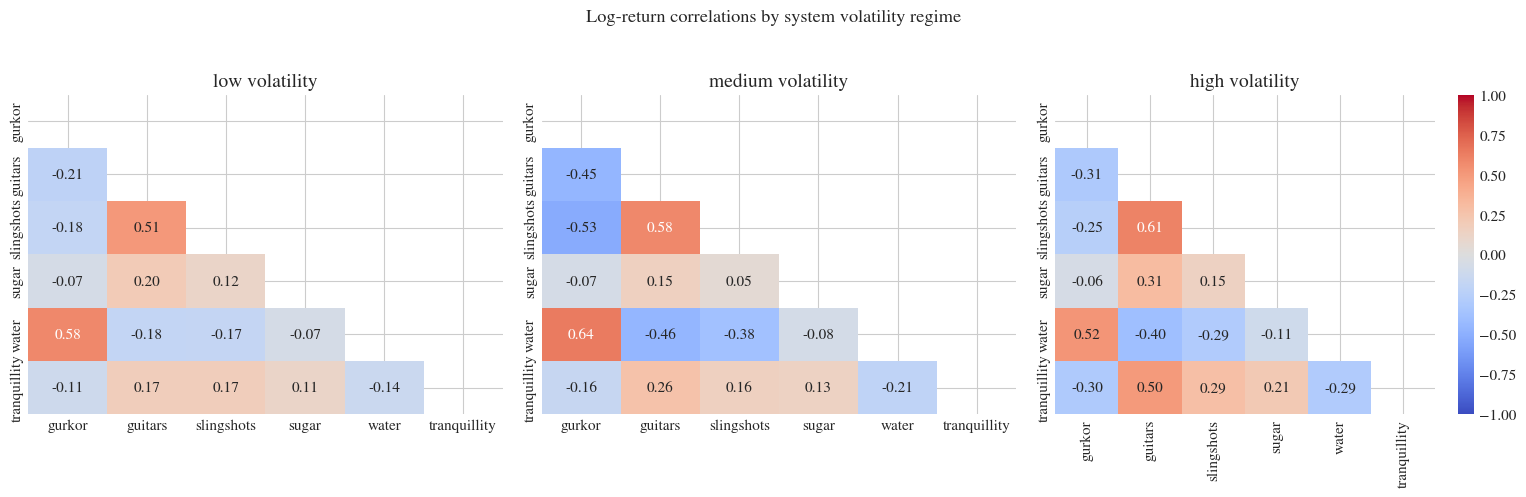

,pair,full_sample_correlation,low,medium,high,high_minus_low,n_low,n_medium,n_high
2,guitars vs tranquillity,0.224,0.175,0.264,0.496,0.322,4511,326,207
10,slingshots vs tranquillity,0.189,0.174,0.155,0.287,0.112,4511,326,207
1,guitars vs sugar,0.212,0.198,0.148,0.305,0.107,4511,326,207
0,guitars vs slingshots,0.526,0.506,0.581,0.607,0.101,4511,326,207
12,sugar vs tranquillity,0.127,0.111,0.133,0.211,0.100,4511,326,207
9,slingshots vs sugar,0.118,0.115,0.050,0.148,0.032,4511,326,207
6,gurkor vs sugar,-0.067,-0.068,-0.069,-0.056,0.012,4511,326,207
13,sugar vs water,-0.071,-0.068,-0.076,-0.109,-0.041,4511,326,207
8,gurkor vs water,0.573,0.583,0.639,0.517,-0.066,4511,326,207
5,gurkor vs slingshots,-0.217,-0.181,-0.531,-0.251,-0.070,4511,326,207


In [65]:
regime_corr_min_observations = 100

system_conditional_corr_matrices = regime_conditional_correlation_matrices(
    regime_return_data,
    system_volatility_state,
    labels=volatility_regime_labels,
    min_observations=regime_corr_min_observations,
)
system_conditional_corr_summary = regime_conditional_correlation_summary(
    regime_return_data,
    system_volatility_state,
    labels=volatility_regime_labels,
    min_observations=regime_corr_min_observations,
)
system_conditional_corr_wide = wide_regime_correlation_summary(
    system_conditional_corr_summary,
    labels=volatility_regime_labels,
)
system_corr_display_cols = [
    "pair",
    "full_sample_correlation",
    "low",
    "medium",
    "high",
    "high_minus_low",
    "n_low",
    "n_medium",
    "n_high",
]

plot_regime_conditional_correlation_matrices(
    system_conditional_corr_matrices,
    output / "system_volatility_regime_correlations.png",
    "Log-return correlations by system volatility regime",
    labels=volatility_regime_labels,
)

display(system_conditional_corr_wide[system_corr_display_cols].sort_values("high_minus_low", ascending=False).round(3))



system_conditional_corr_wide[system_corr_display_cols].to_latex(
    output / "SystemRegimeConditionalCorrelations.tex",
    index=False,
    float_format=lambda value: f"{value:.3g}",
)


The system view asks whether correlations change when the whole panel is calm or turbulent. The pair-specific view below asks a narrower question: does a pair move together differently when both assets themselves are in the same volatility regime?


These tables separate correlation level from volatility state. With the persistent data-driven regimes, the main pattern is still asymmetric: high-volatility regimes strengthen the positive links among `guitars`, `slingshots`, and `tranquillity`, while they make the negative links between the `gurkor`/`water` side and the `guitars`/`slingshots` side much more negative.

In the system-regime view, `guitars`--`tranquillity` moves from about 0.03 in low volatility to about 0.37 in high volatility, and `guitars`--`slingshots` rises from about 0.44 to about 0.60. In contrast, `guitars`--`water` moves from about 0.15 to about -0.49, while `gurkor`--`guitars` moves from about -0.01 to about -0.41.

The robust exception is `gurkor`--`water`: it remains strongly positive across volatility states. So the regime effect does not replace the static grouping result; it refines it by showing which relationships strengthen, weaken, or flip during persistent turbulent periods.


## 12. Conclusions

Main conclusions from Task 1:

- Cleaning matters immediately: there are 5 corrupted all-1000 rows, one 50-day internal gap per asset, and a shared 200-day trailing gap. These are not random small omissions; they directly shape interpolation and extrapolation in later tasks.
- Price levels are nonstationary and highly persistent. ADF and KPSS agree on nonstationarity for all cleaned price series, and the cleaned-price ACF stays significant through lag 500 for every asset.
- Log-returns are stationary by both ADF and KPSS and are the right object for dependence analysis.
- Return volatility differs sharply across assets. `gurkor` and `water` are low-volatility assets, while `sugar`, `stocks`, `guitars`, and `slingshots` are much more volatile.
- Linear return autocorrelation is modest. Ljung-Box tests reject for `gurkor`, `guitars`, `slingshots`, and `sugar`, but not for `stocks`, `water`, and only weakly for `tranquillity` at lag 20.
- Volatility clustering is the dominant within-series pattern. Ljung-Box tests on $|r_t|$ and $r_t^2$ reject strongly for every asset except `stocks`.
- The rolling-volatility regime classification uses a data-driven GMM/BIC rule on log rolling volatility plus a 21-day minimum-spell filter, so regime sizes are not forced to be one third each and short flickers are not treated as regimes; `stocks` remains the weak-clustering exception.
- Seasonality is weak. Periodograms of detrended log-prices are dominated by long low-frequency cycles; the annual 252-day band is visible in some assets but not strong enough to be the main explanation.
- Cross-series dependence has two robust positive pairs: `gurkor`-`water` with correlation about 0.57 and `guitars`-`slingshots` with correlation about 0.53. The strongest negative pair is `gurkor`-`guitars`, about -0.24.
- Grouping is useful but approximate. Direct correlations and rolling threshold stability should drive the cross-series grouping interpretation: `{gurkor, water}` and `{guitars, slingshots}` are the core positive pairs, while `stocks`, `sugar`, and `tranquillity` are less cleanly committed to a stable positive group.
- Regime-conditioned correlations show that turbulent periods sharpen relationships: `guitars`--`slingshots` and `guitars`--`tranquillity` strengthen, while cross-side links such as `guitars`--`water` and `gurkor`--`guitars` become much more negative.
